# Notebook 15: Empirical Event Study and Predictive Dependence

This notebook evaluates whether scheduled Bank of Japan (BoJ) and FOMC decisions coincide with, or predict, changes in USD/JPY one-month ATM implied volatility. It reports descriptive event-study, predictive Granger-style, and lagged-dependence evidence; none is interventionist causal identification.

## 1. Research Question and Scope

The analysis preserves the Notebook 14 canonical panel, event calendars, samples, and both daily alignment conventions. The central limitation is that a daily IV fixing time is not observed, so same-date and next-observation interpretations are reported side by side.

## 2. Imports and Deterministic Configuration

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

SEED = 1501
rng = np.random.default_rng(SEED)
N_BOOTSTRAP = 2000
N_PLACEBO_DRAWS = 1000
CI_LEVEL = 0.95
LOWER_Q, UPPER_Q = 2.5, 97.5
AGES = np.arange(-20, 11)
ESTIMANDS = ['pre_5_to_1', 'event_day', 'post_1', 'post_5', 'post_10']
ROOT = Path.cwd()
NOTEBOOK_PATH = ROOT / '15_empirical_event_study_and_causality.ipynb'
N14 = ROOT / 'notebook14_results'
OUT = ROOT / 'notebook15_results'
FIGURES = OUT / 'figures'
OUT.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
assert N14.is_dir(), 'Notebook 14 results are required.'

## 3. Data and Event Definitions

In [2]:
INPUTS = {
    'canonical_daily_panel.csv': N14 / 'usdjpy_daily_spot_1m_atm_panel.csv',
    'central_bank_decisions_clean.csv': N14 / 'central_bank_decisions_clean.csv',
    'event_alignment_same_date.csv': N14 / 'event_alignment_same_date.csv',
    'event_alignment_next_observation.csv': N14 / 'event_alignment_next_observation.csv',
    'event_windows_same_date.csv': N14 / 'event_windows_same_date.csv',
    'event_windows_next_observation.csv': N14 / 'event_windows_next_observation.csv',
    'event_window_coverage.csv': N14 / 'event_window_coverage.csv',
    'manifest.json': N14 / 'manifest.json',
}
missing = [name for name, path in INPUTS.items() if not path.exists()]
assert not missing, f'Missing checkpoints: {missing}'
panel = pd.read_csv(INPUTS['canonical_daily_panel.csv'], parse_dates=['date'])
events = pd.read_csv(INPUTS['central_bank_decisions_clean.csv'], parse_dates=['local_event_date'])
same = pd.read_csv(INPUTS['event_alignment_same_date.csv'], parse_dates=['local_event_date', 'aligned_market_date'])
next_obs = pd.read_csv(INPUTS['event_alignment_next_observation.csv'], parse_dates=['local_event_date', 'aligned_market_date'])
windows_same = pd.read_csv(INPUTS['event_windows_same_date.csv'], parse_dates=['event_date', 'aligned_date', 'market_date'])
windows_next = pd.read_csv(INPUTS['event_windows_next_observation.csv'], parse_dates=['event_date', 'aligned_date', 'market_date'])
coverage = pd.read_csv(INPUTS['event_window_coverage.csv'], parse_dates=['local_event_date', 'aligned_market_date'])
n14_manifest = json.loads(INPUTS['manifest.json'].read_text(encoding='utf-8'))
assert {'date','spot_mid','atm_1m_iv','atm_1m_div','atm_1m_dlogiv','spot_log_return_pct'}.issubset(panel.columns)
assert {'event_id','central_bank','local_event_date','event'}.issubset(events.columns)


## 4. Checkpoint and Sample Validation

Checkpoint failures are raised rather than repaired. Same-date remains first-reported; next-observation is the fixing-time sensitivity.

In [3]:
def check_window(name, frame):
    sizes = frame.groupby('event_id').size()
    return {'checkpoint': name, 'rows': len(frame), 'events': frame['event_id'].nunique(), 'age_min': frame.event_age.min(), 'age_max': frame.event_age.max(), 'rows_per_event_ok': sizes.eq(31).all()}

validation = pd.DataFrame([
    {'checkpoint':'canonical_daily_panel.csv','rows':len(panel),'events':np.nan,'age_min':np.nan,'age_max':np.nan,'rows_per_event_ok':np.nan},
    check_window('event_windows_same_date.csv', windows_same),
    check_window('event_windows_next_observation.csv', windows_next),
])
assert len(panel) == 7922 and panel.date.min() == pd.Timestamp('1995-12-04') and panel.date.max() == pd.Timestamp('2026-06-10')
assert panel.date.is_unique and panel[['spot_mid','atm_1m_iv']].notna().all().all()
for name, frame in [('same_date',windows_same),('next_observation',windows_next)]:
    assert len(frame) == 4247 and frame.event_id.nunique() == 137, f'{name} event-window size failed'
    assert frame.groupby('event_id').size().eq(31).all() and set(frame.event_age) == set(AGES)
coverage_counts = coverage.groupby(['alignment_convention','central_bank'],as_index=False).agg(events=('event_id','nunique'),post_clean=('clean_post_window_flag','sum'),strict_clean=('strict_clean_full_window_flag','sum'))
for convention in ['same_date','next_observation']:
    x = coverage_counts[coverage_counts.alignment_convention.eq(convention)].set_index('central_bank')
    assert x.loc['BoJ', ['events','post_clean','strict_clean']].tolist() == [98,76,46]
    assert x.loc['FOMC', ['events','post_clean','strict_clean']].tolist() == [39,19,0]
assert events.event_id.nunique() == 139 and not events.event.astype(str).str.contains('Minutes',case=False,na=False).any()


### 4.1 Empirical Samples and Event-Level Outcomes

In [4]:
COMMON_START = pd.Timestamp('2021-07-28')
registry_rows = []
for _, row in coverage.iterrows():
    rules = {
        'all_usable_in_panel': bool(row.complete_window_flag),
        'common_comparison_period': bool(row.complete_window_flag and row.local_event_date >= COMMON_START),
        'post_window_clean': bool(row.complete_window_flag and row.clean_post_window_flag),
        'strict_full_window_clean': bool(row.complete_window_flag and row.strict_clean_full_window_flag),
    }
    for sample_name, included in rules.items():
        registry_rows.append({
            'alignment_convention':row.alignment_convention,'central_bank':row.central_bank,'sample_name':sample_name,'event_id':row.event_id,
            'local_event_date':row.local_event_date,'aligned_market_date':row.aligned_market_date,'event_time_index':row.event_time_index,
            'complete_window_flag':row.complete_window_flag,'other_decision_in_full_window_flag':row.other_decision_in_full_window_flag,
            'other_decision_in_post_window_flag':row.other_decision_in_post_window_flag,'strict_clean_full_window_flag':row.strict_clean_full_window_flag,
            'clean_post_window_flag':row.clean_post_window_flag,'inclusion_flag':included,
        })
event_sample_registry = pd.DataFrame(registry_rows)
registry_counts = event_sample_registry.query('inclusion_flag').groupby(['alignment_convention','central_bank','sample_name'],as_index=False).agg(events=('event_id','nunique'))
for convention in ['same_date','next_observation']:
    x = registry_counts.query('alignment_convention == @convention').set_index(['central_bank','sample_name']).events
    assert x.loc[('BoJ','all_usable_in_panel')] == 98 and x.loc[('FOMC','all_usable_in_panel')] == 39
    assert x.loc[('BoJ','common_comparison_period')] == 38 and x.loc[('FOMC','common_comparison_period')] == 39
    assert x.loc[('BoJ','post_window_clean')] == 76 and x.loc[('FOMC','post_window_clean')] == 19
    assert x.loc[('BoJ','strict_full_window_clean')] == 46 and ('FOMC','strict_full_window_clean') not in x.index

windows = pd.concat([windows_same,windows_next],ignore_index=True)
base = windows.merge(panel[['date','atm_1m_dlogiv','spot_log_return_pct']],left_on='market_date',right_on='date',how='left',validate='many_to_one').drop(columns='date')
pre = base[base.event_age.eq(-1)][['alignment_convention','event_id','atm_1m_iv']].rename(columns={'atm_1m_iv':'iv_pre_event'})
assert pre.groupby(['alignment_convention','event_id']).size().eq(1).all() and pre.iv_pre_event.notna().all()
base = base.merge(pre,on=['alignment_convention','event_id'],how='left',validate='many_to_one')
base['iv_change_from_pre'] = base.atm_1m_iv - base.iv_pre_event
assert base.loc[base.event_age.eq(-1),'iv_change_from_pre'].eq(0).all()
included_registry = event_sample_registry.query('inclusion_flag').copy()
event_level_outcomes = base.merge(included_registry.drop(columns='inclusion_flag'),on=['alignment_convention','central_bank','event_id'],how='inner',validate='many_to_many')
outcome_group_keys = ['alignment_convention', 'sample_name', 'event_id']
assert (
    event_level_outcomes.loc[event_level_outcomes['event_age'].eq(-1)]
    .groupby(outcome_group_keys)
    .size()
    .index
    .equals(event_level_outcomes.groupby(outcome_group_keys).size().index)
)

wide = base.pivot(index=['alignment_convention','central_bank','event_id'],columns='event_age',values='atm_1m_iv').reindex(columns=AGES)
wide['pre_5_to_1'] = wide[-1]-wide[-5]
wide['event_day'] = wide[0]-wide[-1]
wide['post_1'] = wide[1]-wide[-1]
wide['post_5'] = wide[5]-wide[-1]
wide['post_10'] = wide[10]-wide[-1]
event_window_estimands = wide.reset_index().merge(included_registry[['alignment_convention','central_bank','event_id','sample_name','local_event_date','aligned_market_date','event_time_index']],on=['alignment_convention','central_bank','event_id'],how='inner',validate='one_to_many')


## 5. Empirical Event Study

### 5.1 Event-Time Profiles and Uncertainty

### 5.2 Pre-Specified Event-Window Estimands

In [5]:
PROFILE_OUTCOMES = ['iv_change_from_pre','atm_1m_div','atm_1m_dlogiv','spot_log_return_pct']
GROUPS = ['alignment_convention','central_bank','sample_name']
def bootstrap_paths(values):
    n = len(values)
    idx = rng.integers(0,n,size=(N_BOOTSTRAP,n))
    return np.percentile(values[idx].mean(axis=1),[LOWER_Q,UPPER_Q],axis=0)

profile_rows = []
for keys, group in event_level_outcomes.groupby(GROUPS,sort=True):
    for outcome in PROFILE_OUTCOMES:
        path = group.pivot(index='event_id',columns='event_age',values=outcome).reindex(columns=AGES)
        values = path.to_numpy(float)
        assert np.isfinite(values).all(), f'Incomplete profile path: {keys}, {outcome}'
        lo, hi = bootstrap_paths(values)
        for j, age in enumerate(AGES):
            v = values[:,j]
            profile_rows.append(dict(zip(GROUPS,keys)) | {'outcome':outcome,'event_age':age,'events':len(v),'mean':v.mean(),'median':np.median(v),'std':v.std(ddof=1),'p02_5':np.percentile(v,2.5),'p25':np.percentile(v,25),'p75':np.percentile(v,75),'p97_5':np.percentile(v,97.5),'bootstrap_ci_lower':lo[j],'bootstrap_ci_upper':hi[j]})
event_time_profiles = pd.DataFrame(profile_rows)

summary_rows = []
for keys, group in event_window_estimands.groupby(GROUPS,sort=True):
    for estimand in ESTIMANDS:
        v = group[estimand].to_numpy(float)
        idx = rng.integers(0,len(v),size=(N_BOOTSTRAP,len(v)))
        draw_means = v[idx].mean(axis=1)
        summary_rows.append(dict(zip(GROUPS,keys)) | {'estimand':estimand,'events':len(v),'mean':v.mean(),'median':np.median(v),'std':v.std(ddof=1),'bootstrap_ci_lower':np.percentile(draw_means,LOWER_Q),'bootstrap_ci_upper':np.percentile(draw_means,UPPER_Q),'proportion_positive':(v>0).mean()})
event_window_estimand_summary = pd.DataFrame(summary_rows)


### 5.3 Matched Non-Event Placebo Comparison

In [6]:
panel_iv = panel.atm_1m_iv.to_numpy(float)
panel_dates = panel.date.reset_index(drop=True)
alignments = pd.concat([same, next_obs], ignore_index=True)

def iv_estimands(indices):
    i = np.asarray(indices, int)
    return np.column_stack([
        panel_iv[i - 1] - panel_iv[i - 5],
        panel_iv[i] - panel_iv[i - 1],
        panel_iv[i + 1] - panel_iv[i - 1],
        panel_iv[i + 5] - panel_iv[i - 1],
        panel_iv[i + 10] - panel_iv[i - 1],
    ])

def eligible_indices_for(convention, sample_start, sample_end):
    actual_alignment = alignments.query(
        'alignment_convention == @convention and not event_outside_panel'
    )
    blocked_candidates = {
        candidate_index
        for real_event_index in actual_alignment['event_time_index'].astype(int)
        for candidate_index in range(real_event_index - 10, real_event_index + 6)
    }
    candidate_index = np.arange(20, len(panel) - 10)
    inside_support = (
        (panel_dates.iloc[candidate_index] >= sample_start)
        & (panel_dates.iloc[candidate_index] <= sample_end)
    )
    return np.asarray(
        [index for index in candidate_index[inside_support] if index not in blocked_candidates],
        dtype=int,
    )

def exact_year_weekday_candidates(actual_date, eligible_indices):
    candidate_dates = panel_dates.iloc[eligible_indices]
    exact_candidates = eligible_indices[
        (candidate_dates.dt.year.to_numpy() == actual_date.year)
        & (candidate_dates.dt.dayofweek.to_numpy() == actual_date.dayofweek)
    ]
    return np.asarray(exact_candidates, dtype=int)

def bh_adjust(p_values):
    p_values = np.asarray(p_values, float)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order] * n / np.arange(1, n + 1)
    adjusted_ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty(n, float)
    adjusted[order] = np.minimum(adjusted_ranked, 1.0)
    return adjusted

def placebo_support(convention, sample_name, actual_events):
    if sample_name == 'common_comparison_period':
        common_actual = included_registry.loc[
            included_registry['sample_name'].eq('common_comparison_period')
            & included_registry['alignment_convention'].eq(convention)
        ].drop_duplicates('event_id')
        return common_actual['aligned_market_date'].min(), common_actual['aligned_market_date'].max()
    return actual_events['aligned_market_date'].min(), actual_events['aligned_market_date'].max()

placebo_rows, placebo_diag_rows, placebo_draw_diag_rows = [], [], []
for keys, actual in included_registry.groupby(GROUPS, sort=True):
    convention, bank, sample = keys
    actual = actual.drop_duplicates('event_id').sort_values('event_id').reset_index(drop=True)
    sample_start, sample_end = placebo_support(convention, sample, actual)
    eligible_indices = eligible_indices_for(convention, sample_start, sample_end)
    candidate_sets = []
    for _, event in actual.iterrows():
        exact_candidates = exact_year_weekday_candidates(
            event.aligned_market_date, eligible_indices
        )
        if len(exact_candidates) == 0:
            print(
                'No exact placebo candidate:',
                f"event_id={event.event_id}, bank={bank}, alignment={convention}, "
                f"sample={sample}, year={event.aligned_market_date.year}, "
                f"weekday={event.aligned_market_date.dayofweek}",
            )
            raise AssertionError(f'No exact year-and-weekday placebo candidate for {event.event_id}')
        candidate_sets.append(exact_candidates)
        placebo_diag_rows.append({
            'alignment_convention': convention,
            'central_bank': bank,
            'sample_name': sample,
            'event_id': event.event_id,
            'actual_aligned_date': event.aligned_market_date,
            'sample_period_start': sample_start,
            'sample_period_end': sample_end,
            'exact_candidate_count': len(exact_candidates),
            'adjacent_year_matching_required': False,
        })

    draws = np.empty((N_PLACEBO_DRAWS, len(ESTIMANDS)))
    number_of_events = len(actual)
    for draw in range(N_PLACEBO_DRAWS):
        assignment_order = rng.permutation(number_of_events)
        used_dates, chosen_dates = set(), [None] * number_of_events
        for event_position in assignment_order:
            available = np.asarray(
                [index for index in candidate_sets[event_position] if index not in used_dates],
                dtype=int,
            )
            if len(available) == 0:
                event = actual.iloc[event_position]
                raise RuntimeError(
                    f'No unused placebo date for {event.event_id} in draw {draw}; '
                    'pseudo-event dates may not be reused.'
                )
            choice = int(rng.choice(available))
            used_dates.add(choice)
            chosen_dates[event_position] = choice
        assert len(chosen_dates) == number_of_events
        assert len(set(chosen_dates)) == number_of_events
        draws[draw] = iv_estimands(chosen_dates).mean(axis=0)
        placebo_draw_diag_rows.append({
            'alignment_convention': convention,
            'central_bank': bank,
            'sample_name': sample,
            'draw_number': draw + 1,
            'requested_event_count': number_of_events,
            'chosen_date_count': len(chosen_dates),
            'unique_chosen_date_count': len(set(chosen_dates)),
            'duplicate_chosen_date_count': len(chosen_dates) - len(set(chosen_dates)),
            'fallback_reuse_count': 0,
        })

    actual_values = event_window_estimands.query(
        'alignment_convention == @convention and central_bank == @bank and sample_name == @sample'
    )[ESTIMANDS].to_numpy(float)
    assert len(actual_values) == number_of_events
    actual_means = actual_values.mean(axis=0)
    for j, name in enumerate(ESTIMANDS):
        placebo_statistics = draws[:, j]
        placebo_centre = placebo_statistics.mean()
        empirical_p_value = (
            1
            + (
                np.abs(placebo_statistics - placebo_centre)
                >= np.abs(actual_means[j] - placebo_centre)
            ).sum()
        ) / (1 + N_PLACEBO_DRAWS)
        placebo_rows.append({
            'alignment_convention': convention,
            'central_bank': bank,
            'sample_name': sample,
            'estimand': name,
            'events': number_of_events,
            'actual_mean': actual_means[j],
            'placebo_mean': placebo_centre,
            'actual_minus_placebo_mean': actual_means[j] - placebo_centre,
            'placebo_ci_lower': np.percentile(placebo_statistics, LOWER_Q),
            'placebo_ci_upper': np.percentile(placebo_statistics, UPPER_Q),
            'empirical_two_sided_p_value': empirical_p_value,
        })

placebo_calendar_diagnostics = pd.DataFrame(placebo_diag_rows)
for _, index in placebo_calendar_diagnostics.groupby(GROUPS).groups.items():
    counts = placebo_calendar_diagnostics.loc[index, 'exact_candidate_count']
    placebo_calendar_diagnostics.loc[index, 'candidate_count_minimum_by_sample'] = counts.min()
    placebo_calendar_diagnostics.loc[index, 'candidate_count_median_by_sample'] = counts.median()
    placebo_calendar_diagnostics.loc[index, 'candidate_count_maximum_by_sample'] = counts.max()

placebo_draw_diagnostics = pd.DataFrame(placebo_draw_diag_rows)
assert placebo_draw_diagnostics['chosen_date_count'].eq(placebo_draw_diagnostics['requested_event_count']).all()
assert placebo_draw_diagnostics['unique_chosen_date_count'].eq(placebo_draw_diagnostics['requested_event_count']).all()
assert placebo_draw_diagnostics['duplicate_chosen_date_count'].eq(0).all()
assert placebo_draw_diagnostics['fallback_reuse_count'].eq(0).all()
assert not placebo_calendar_diagnostics['adjacent_year_matching_required'].any()

placebo_comparison_summary = pd.DataFrame(placebo_rows)
placebo_comparison_summary['bh_adjusted_q_value'] = np.nan
for _, index in placebo_comparison_summary.groupby(GROUPS).groups.items():
    p_values = placebo_comparison_summary.loc[index, 'empirical_two_sided_p_value'].to_numpy(float)
    placebo_comparison_summary.loc[index, 'bh_adjusted_q_value'] = bh_adjust(p_values)
placebo_comparison_summary['significant_unadjusted_5pct'] = placebo_comparison_summary['empirical_two_sided_p_value'].lt(0.05)
placebo_comparison_summary['significant_bh_5pct'] = placebo_comparison_summary['bh_adjusted_q_value'].lt(0.05)


### 5.4 Common-Period and Alignment Sensitivity

In [7]:
comparison_rows = []
common = event_window_estimands.query("sample_name == 'common_comparison_period'")
for convention, group in common.groupby('alignment_convention'):
    for name in ESTIMANDS:
        f = group.loc[group.central_bank.eq('FOMC'),name].to_numpy(float)
        b = group.loc[group.central_bank.eq('BoJ'),name].to_numpy(float)
        fd = f[rng.integers(0,len(f),size=(N_BOOTSTRAP,len(f)))].mean(axis=1)
        bd = b[rng.integers(0,len(b),size=(N_BOOTSTRAP,len(b)))].mean(axis=1)
        d = fd-bd
        comparison_rows.append({'alignment_convention':convention,'estimand':name,'fomc_events':len(f),'boj_events':len(b),'fomc_mean':f.mean(),'boj_mean':b.mean(),'fomc_minus_boj':f.mean()-b.mean(),'bootstrap_ci_lower':np.percentile(d,LOWER_Q),'bootstrap_ci_upper':np.percentile(d,UPPER_Q)})
common_period_bank_comparison = pd.DataFrame(comparison_rows)

long = event_window_estimands.melt(id_vars=['alignment_convention','central_bank','sample_name','event_id'],value_vars=ESTIMANDS,var_name='estimand',value_name='estimate')
paired = long.pivot(index=['central_bank','sample_name','event_id','estimand'],columns='alignment_convention',values='estimate').dropna(subset=['same_date','next_observation']).reset_index()
paired['same_minus_next'] = paired.same_date-paired.next_observation
sensitivity_rows=[]
for keys, group in paired.groupby(['central_bank','sample_name','estimand']):
    sm, nm = group.same_date.mean(), group.next_observation.mean()
    rule = 'stable direction' if np.sign(sm) == np.sign(nm) else 'alignment-sensitive direction'
    sensitivity_rows.append({'central_bank':keys[0],'sample_name':keys[1],'estimand':keys[2],'paired_events':len(group),'mean_difference':group.same_minus_next.mean(),'median_difference':group.same_minus_next.median(),'mean_absolute_difference':group.same_minus_next.abs().mean(),'correlation':group.same_date.corr(group.next_observation),'proportion_same_sign':(np.sign(group.same_date)==np.sign(group.next_observation)).mean(),'substantive_direction_rule':rule})
alignment_sensitivity_summary = pd.DataFrame(sensitivity_rows)


### 5.5 Event-Study Figures

BoJ is red and FOMC is black. The plots show descriptive event-time patterns and uncertainty, not causal effects.

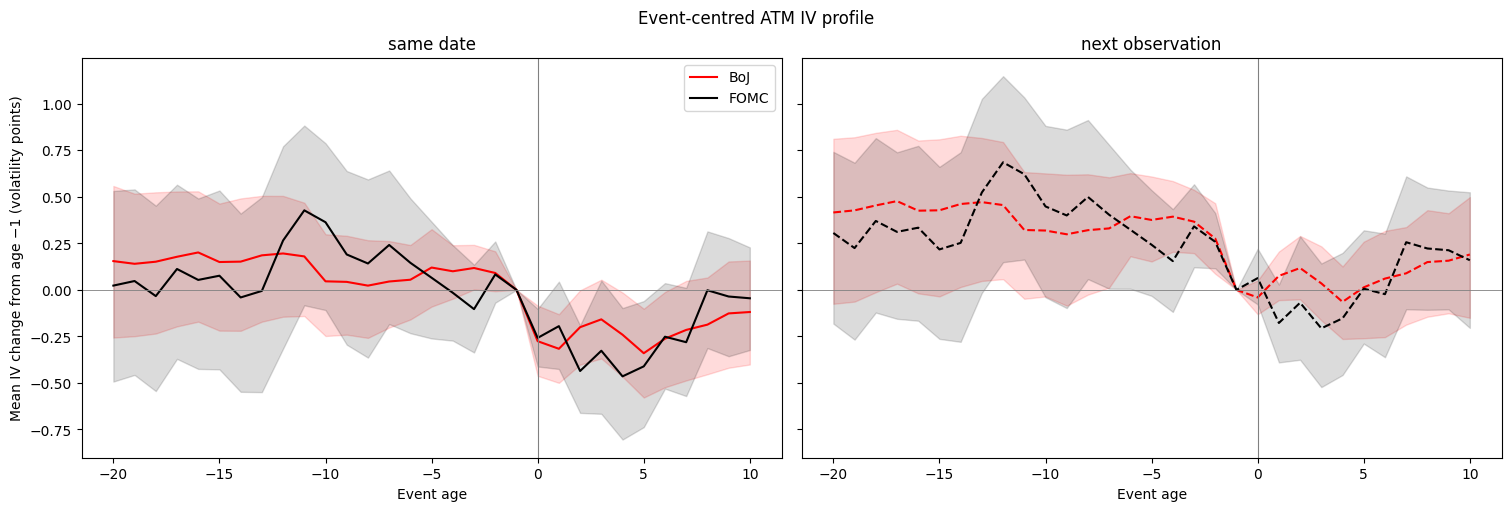

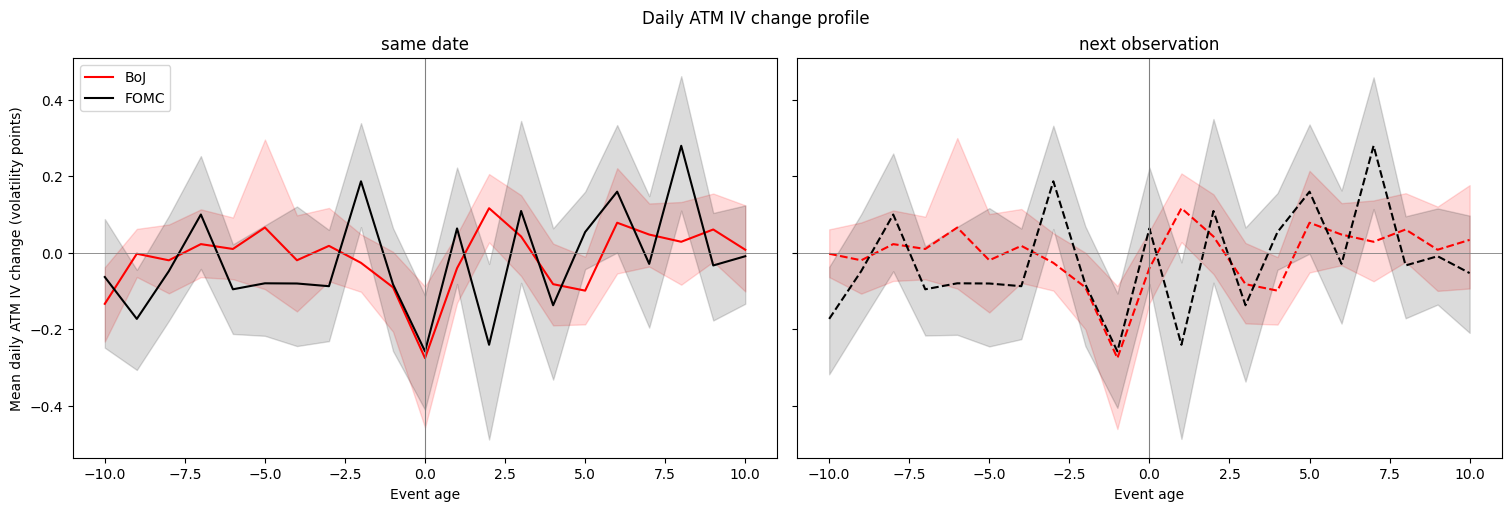

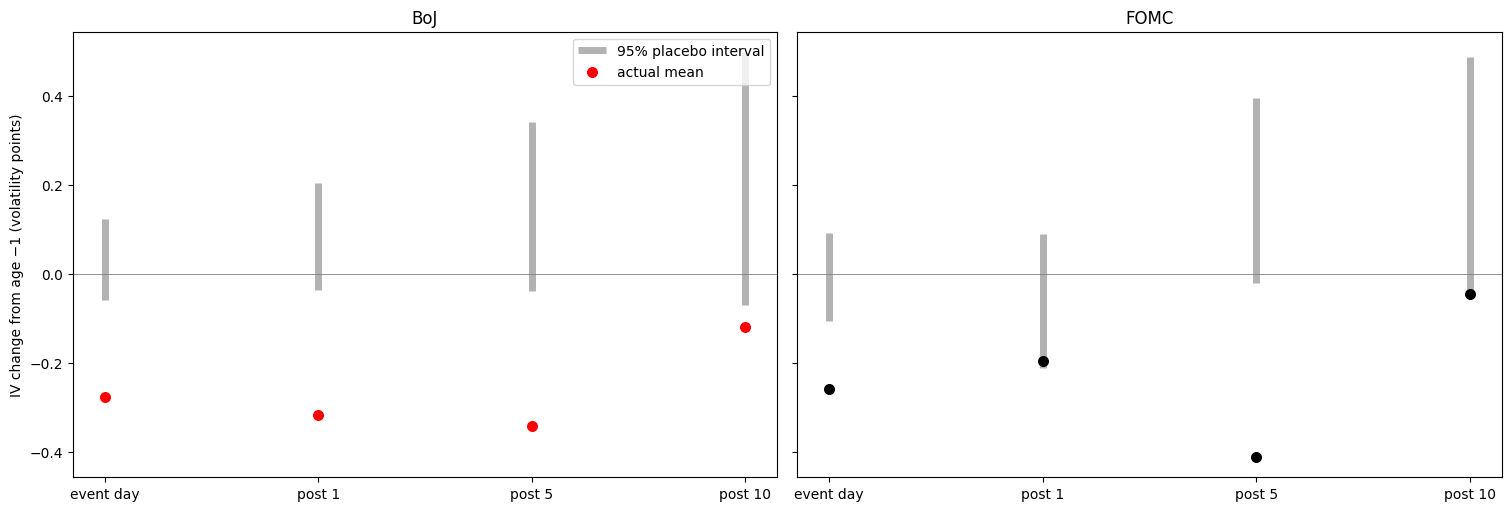

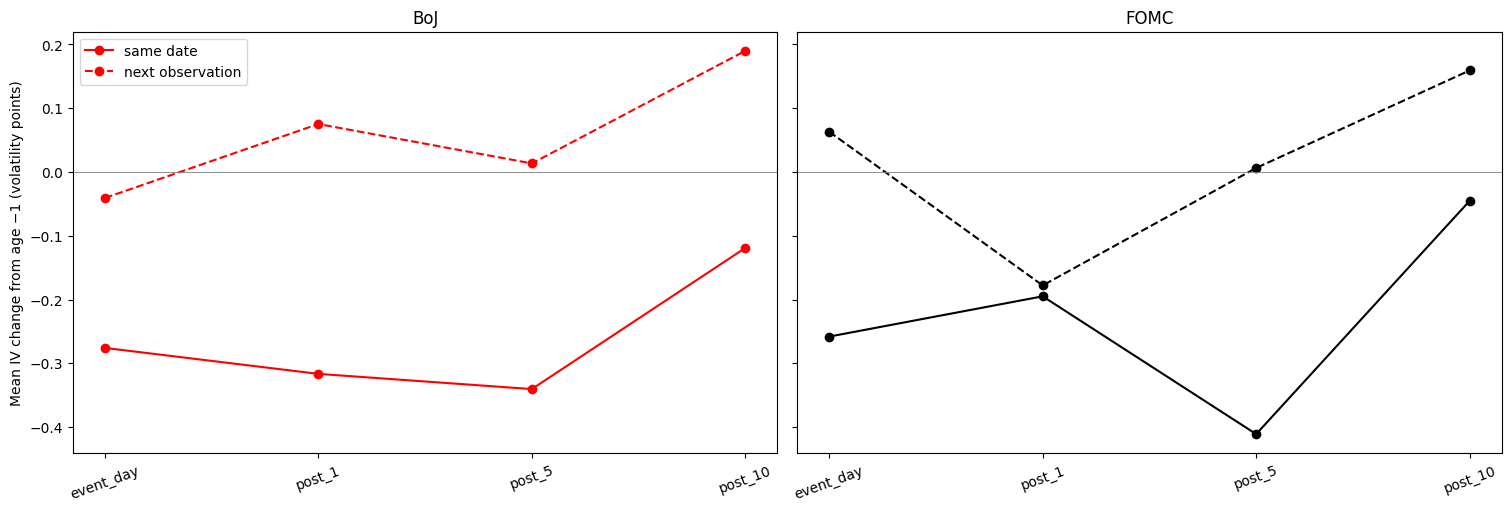

In [8]:
COLORS={'BoJ':'red','FOMC':'black'}
STYLES={'same_date':'-','next_observation':'--'}
def profile_figure(outcome,ages,filename,ylabel,title):
    fig, axes = plt.subplots(1,2,figsize=(15,5),sharey=True,constrained_layout=True)
    for axis, convention in zip(axes,['same_date','next_observation']):
        q = event_time_profiles.query("alignment_convention == @convention and sample_name == 'all_usable_in_panel' and outcome == @outcome and event_age in @ages")
        for bank in ['BoJ','FOMC']:
            x=q[q.central_bank.eq(bank)]
            axis.plot(x.event_age,x['mean'],color=COLORS[bank],linestyle=STYLES[convention],label=bank)
            axis.fill_between(x.event_age,x.bootstrap_ci_lower,x.bootstrap_ci_upper,color=COLORS[bank],alpha=.14)
        axis.axvline(0,color='grey',lw=.8); axis.axhline(0,color='grey',lw=.6); axis.set_title(convention.replace('_',' ')); axis.set_xlabel('Event age')
    axes[0].set_ylabel(ylabel); axes[0].legend(); fig.suptitle(title)
    fig.savefig(FIGURES/filename,dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
profile_figure('iv_change_from_pre',AGES,'figure_1_event_centred_iv_profile.png','Mean IV change from age −1 (volatility points)','Event-centred ATM IV profile')
profile_figure('atm_1m_div',np.arange(-10,11),'figure_2_daily_iv_change_profile.png','Mean daily ATM IV change (volatility points)','Daily ATM IV change profile')

plot_names=['event_day','post_1','post_5','post_10']
fig3,ax3=plt.subplots(1,2,figsize=(15,5),sharey=True,constrained_layout=True)
for ax,bank in zip(ax3,['BoJ','FOMC']):
    q=placebo_comparison_summary.query("alignment_convention == 'same_date' and sample_name == 'all_usable_in_panel' and central_bank == @bank").set_index('estimand').reindex(plot_names)
    x=np.arange(len(plot_names)); ax.vlines(x,q.placebo_ci_lower,q.placebo_ci_upper,color='grey',lw=5,alpha=.6,label='95% placebo interval'); ax.scatter(x,q.actual_mean,color=COLORS[bank],s=48,label='actual mean',zorder=3); ax.axhline(0,color='grey',lw=.6); ax.set_xticks(x,['event day','post 1','post 5','post 10']); ax.set_title(bank)
ax3[0].set_ylabel('IV change from age −1 (volatility points)'); ax3[0].legend(); fig3.savefig(FIGURES/'figure_3_estimands_vs_placebo.png',dpi=160,bbox_inches='tight'); display(fig3); plt.close(fig3)

fig4,ax4=plt.subplots(1,2,figsize=(15,5),sharey=True,constrained_layout=True)
for ax,bank in zip(ax4,['BoJ','FOMC']):
    q=event_window_estimand_summary.query("central_bank == @bank and sample_name == 'all_usable_in_panel' and estimand in @plot_names")
    for convention in ['same_date','next_observation']:
        x=q[q.alignment_convention.eq(convention)].set_index('estimand').reindex(plot_names); ax.plot(plot_names,x['mean'],color=COLORS[bank],linestyle=STYLES[convention],marker='o',label=convention.replace('_',' '))
    ax.axhline(0,color='grey',lw=.6); ax.set_title(bank); ax.tick_params(axis='x',rotation=20)
ax4[0].set_ylabel('Mean IV change from age −1 (volatility points)'); ax4[0].legend(); fig4.savefig(FIGURES/'figure_4_alignment_sensitivity.png',dpi=160,bbox_inches='tight'); display(fig4); plt.close(fig4)


Internal event-study checks remain in the code and are summarised in the compact validation section.

In [9]:
candidate_by_bank=placebo_calendar_diagnostics.groupby('central_bank')['exact_candidate_count'].agg(['min','median']).reset_index()
draw_totals=placebo_draw_diagnostics[['duplicate_chosen_date_count','fallback_reuse_count']].sum()
numeric_summary=pd.DataFrame([{'metric':'panel_rows','value':len(panel)},{'metric':'bootstrap_replications','value':N_BOOTSTRAP},{'metric':'placebo_draws','value':N_PLACEBO_DRAWS},{'metric':'same_window_rows','value':len(windows_same)},{'metric':'next_window_rows','value':len(windows_next)},{'metric':'adjacent_year_placebo_matches','value':int(placebo_calendar_diagnostics.adjacent_year_matching_required.sum())},{'metric':'duplicate_pseudo_dates','value':int(draw_totals['duplicate_chosen_date_count'])},{'metric':'fallback_reuse_count','value':int(draw_totals['fallback_reuse_count'])}])
figure_files=sorted(path.name for path in FIGURES.glob('figure_[1-4]_*.png'))
assert len(figure_files)==4
assert not placebo_calendar_diagnostics['adjacent_year_matching_required'].any()
assert draw_totals['duplicate_chosen_date_count']==0 and draw_totals['fallback_reuse_count']==0

The Phase A results are combined with the predictive and dependence evidence in the final empirical interpretation.

In [10]:
def direction(value): return 'rises' if value>0 else ('falls' if value<0 else 'is unchanged')
def alignment_description(same_row,next_row):
 same_sign=np.sign(same_row['mean'])==np.sign(next_row['mean']); same_excludes=(same_row['bootstrap_ci_lower']>0) or (same_row['bootstrap_ci_upper']<0); next_excludes=(next_row['bootstrap_ci_lower']>0) or (next_row['bootstrap_ci_upper']<0)
 return 'alignment-sensitive' if not same_sign else ('robust across alignments' if same_excludes and next_excludes else 'same direction but weaker under one alignment')
phase_a_findings=[]
for bank in ['BoJ','FOMC']:
 same_row=event_window_estimand_summary.query("alignment_convention == 'same_date' and central_bank == @bank and sample_name == 'all_usable_in_panel' and estimand == 'event_day'").iloc[0]
 next_row=event_window_estimand_summary.query("alignment_convention == 'next_observation' and central_bank == @bank and sample_name == 'all_usable_in_panel' and estimand == 'event_day'").iloc[0]
 placebo=placebo_comparison_summary.query("alignment_convention == 'same_date' and central_bank == @bank and sample_name == 'all_usable_in_panel' and estimand == 'event_day'").iloc[0]
 phase_a_findings.append({'bank':bank,'same_date_mean':same_row['mean'],'next_observation_mean':next_row['mean'],'placebo_q_value':placebo['bh_adjusted_q_value'],'alignment_interpretation':alignment_description(same_row,next_row),'placebo_supported':bool(placebo['significant_bh_5pct'])})
phase_a_findings=pd.DataFrame(phase_a_findings)
assert len(panel)==7922 and len(windows_same)==len(windows_next)==4247
assert len(figure_files)==4 and draw_totals['duplicate_chosen_date_count']==0 and draw_totals['fallback_reuse_count']==0

## 6. Granger-Style Predictive Analysis

The following analysis tests whether pre-specified scheduled-event pulses add predictive information beyond the background ARX specification.

### 6.1 Timing Convention and Interpretation

For every aligned response row at panel index *r*, the bank-specific driver pulse is placed at *r - 1*. Lag one in a regression for current IV change is therefore the first aligned response observation. No future IV values are used to form the scheduled driver.

Central-bank decisions are institutionally scheduled and are not plausibly generated by lagged daily implied-volatility changes. A reverse linear Granger regression would have weak economic interpretation. Directional asymmetry may be examined with positive and negative TDMI lags; this omission does not prove one-way causality.

### 6.2 Configuration and Event-Driver Construction

In [11]:
from scipy.stats import chi2, norm

GC_SEED = 1502
gc_rng = np.random.default_rng(GC_SEED)
MAX_AR_LAG = 10
EVENT_LAG_HORIZONS = [1, 2, 5, 10]
N_GC_PERMUTATIONS = 1000
GC_ALPHA = 0.05
GC_OUTCOMES = ['atm_1m_div', 'atm_1m_dlogiv']
GC_PRIMARY_OUTCOME = 'atm_1m_div'
GC_SAMPLE_ORDER = ['all_usable_in_panel', 'common_comparison_period', 'post_window_clean', 'strict_full_window_clean']
assert set(GC_OUTCOMES + ['spot_log_return_pct']).issubset(panel.columns)
assert set(EVENT_LAG_HORIZONS) == {1, 2, 5, 10}

Separate FOMC and BoJ columns retain one pulse in each bank column if decisions map to the same driver row. The audit verifies that every driver precedes its aligned response by exactly one canonical observation.

In [12]:
gc_driver_rows, gc_driver_frames = [], {}
for convention, aligned in [('same_date', same), ('next_observation', next_obs)]:
    drivers = pd.DataFrame({'panel_index': np.arange(len(panel)), 'date': panel.date,
                            'fomc_event_driver': np.zeros(len(panel), int),
                            'boj_event_driver': np.zeros(len(panel), int)})
    for _, event in aligned.loc[~aligned.event_outside_panel].iterrows():
        response_index = int(event.event_time_index)
        driver_index = response_index - 1
        assert response_index - driver_index == 1 and 0 <= driver_index < len(panel)
        column = 'fomc_event_driver' if event.central_bank == 'FOMC' else 'boj_event_driver'
        drivers.loc[driver_index, column] = 1
        gc_driver_rows.append({'alignment_convention': convention, 'event_id': event.event_id,
            'central_bank': event.central_bank, 'local_decision_date': event.local_event_date,
            'aligned_response_date': event.aligned_market_date, 'aligned_response_panel_index': response_index,
            'driver_date': panel.loc[driver_index, 'date'], 'driver_panel_index': driver_index,
            'response_lag_from_driver_observations': response_index - driver_index})
    gc_driver_frames[convention] = drivers
gc_event_driver_audit = pd.DataFrame(gc_driver_rows)
assert gc_event_driver_audit.response_lag_from_driver_observations.eq(1).all()
for convention in ['same_date', 'next_observation']:
    counts = gc_event_driver_audit.query('alignment_convention == @convention').groupby('central_bank').event_id.nunique()
    assert counts.loc['BoJ'] == 98 and counts.loc['FOMC'] == 39
    assert gc_driver_frames[convention].boj_event_driver.sum() == 98
    assert gc_driver_frames[convention].fomc_event_driver.sum() == 39
gc_driver_summary = gc_event_driver_audit.groupby(['alignment_convention', 'central_bank'], as_index=False).agg(
    pulses=('event_id', 'nunique'), response_lag_min=('response_lag_from_driver_observations', 'min'),
    response_lag_max=('response_lag_from_driver_observations', 'max'))


### 6.3 Continuous Regression Samples

Models use continuous canonical daily intervals, not event-window rows. Target pulses follow the event-study sample hierarchy; other-bank pulses remain observed controls. FOMC strict-full-window-clean is unavailable because it has zero retained target events.

In [13]:
def gc_events(convention, bank, sample):
    return included_registry.loc[(included_registry.alignment_convention.eq(convention))
        & (included_registry.central_bank.eq(bank)) & (included_registry.sample_name.eq(sample))].drop_duplicates('event_id').copy()
def gc_pulse(convention, bank, events):
    pulse = np.zeros(len(panel), int)
    chosen = gc_event_driver_audit.loc[(gc_event_driver_audit.alignment_convention.eq(convention))
        & (gc_event_driver_audit.central_bank.eq(bank)) & gc_event_driver_audit.event_id.isin(events.event_id)]
    pulse[chosen.driver_panel_index.to_numpy(int)] = 1
    assert pulse.sum() == len(events)
    return pulse
def gc_bounds(convention, bank, sample):
    if sample == 'common_comparison_period':
        x = included_registry.loc[(included_registry.alignment_convention.eq(convention))
            & (included_registry.sample_name.eq(sample))].drop_duplicates('event_id')
    else:
        x = gc_events(convention, bank, 'all_usable_in_panel')
    return max(0, int(x.event_time_index.min()) - 1 - MAX_AR_LAG), min(len(panel)-1, int(x.event_time_index.max()) + 10)

gc_samples, gc_sample_rows = {}, []
for convention in ['same_date', 'next_observation']:
    for bank in ['BoJ', 'FOMC']:
        other = 'FOMC' if bank == 'BoJ' else 'BoJ'
        other_column = 'fomc_event_driver' if other == 'FOMC' else 'boj_event_driver'
        for sample in GC_SAMPLE_ORDER:
            events_target = gc_events(convention, bank, sample)
            if not len(events_target):
                assert bank == 'FOMC' and sample == 'strict_full_window_clean'
                gc_sample_rows.append({'alignment_convention':convention,'target_bank':bank,'sample_name':sample,
                    'status':'unavailable: zero strict-full-window-clean target events','continuous_observations':0,
                    'target_event_pulse_count':0,'other_bank_pulse_count':np.nan,'start_index':np.nan,'end_index':np.nan,
                    'period_start':pd.NaT,'period_end':pd.NaT})
                continue
            start, end = gc_bounds(convention, bank, sample)
            target = gc_pulse(convention, bank, events_target)
            continuous = panel.loc[start:end, ['date','atm_1m_div','atm_1m_dlogiv','spot_log_return_pct']].copy()
            continuous['panel_index'] = np.arange(start, end+1)
            continuous['target_event_driver'] = target[start:end+1]
            continuous['other_event_driver'] = gc_driver_frames[convention].loc[start:end, other_column].to_numpy(int)
            assert continuous.target_event_driver.sum() == len(events_target)
            gc_samples[(convention,bank,sample)] = continuous.reset_index(drop=True)
            gc_sample_rows.append({'alignment_convention':convention,'target_bank':bank,'sample_name':sample,'status':'estimated',
                'continuous_observations':len(continuous),'target_event_pulse_count':int(continuous.target_event_driver.sum()),
                'other_bank_pulse_count':int(continuous.other_event_driver.sum()),'start_index':start,'end_index':end,
                'period_start':continuous.date.min(),'period_end':continuous.date.max()})
gc_continuous_sample_diagnostics = pd.DataFrame(gc_sample_rows)
for convention in ['same_date','next_observation']:
    common = gc_continuous_sample_diagnostics.query("alignment_convention == @convention and sample_name == 'common_comparison_period' and status == 'estimated'")
    assert common.start_index.nunique() == common.end_index.nunique() == 1
    c = common.set_index('target_bank').target_event_pulse_count
    assert c.loc['BoJ'] == 38 and c.loc['FOMC'] == 39


### 6.4 Autoregressive Order Selection

BIC selects the order from one through ten using outcome and spot lags, weekday effects, and an intercept only. The selected order is fixed across event horizons.

In [14]:
def gc_fit(X, y):
    beta, _, rank, _ = np.linalg.lstsq(X, y, rcond=None)
    residual = y - X @ beta; ssr = float(residual @ residual); n, k = X.shape
    sst = float(((y-y.mean())**2).sum()); r2 = 1-ssr/sst
    ar2 = 1-(1-r2)*(n-1)/(n-k); ll = -.5*n*(np.log(2*np.pi)+1+np.log(ssr/n))
    return dict(beta=beta,residual=residual,ssr=ssr,nobs=n,nvars=k,rank=int(rank),df_resid=n-int(rank),
                r2=r2,adjusted_r2=ar2,aic=-2*ll+2*k,bic=-2*ll+np.log(n)*k,
                residual_std=np.sqrt(ssr/(n-int(rank))),condition_number=float(np.linalg.cond(X)))
def gc_hac(X, residual, maxlags):
    bread = np.linalg.pinv(X.T@X); score = X*residual[:,None]; meat = score.T@score
    for lag in range(1,maxlags+1):
        gamma = score[lag:].T@score[:-lag]; meat += (1-lag/(maxlags+1))*(gamma+gamma.T)
    return bread@meat@bread
def gc_design(frame,outcome,p,L):
    d = frame[['panel_index','date',outcome,'spot_log_return_pct','target_event_driver','other_event_driver']].copy()
    d['sample_row_index'] = np.arange(len(d), dtype=int)
    for lag in range(1,max(p,L)+1):
        if lag <= p:
            d[f'y_{lag}']=d[outcome].shift(lag); d[f'r_{lag}']=d.spot_log_return_pct.shift(lag)
        if lag <= L:
            d[f'target_{lag}']=d.target_event_driver.shift(lag); d[f'other_{lag}']=d.other_event_driver.shift(lag)
    weekday = pd.get_dummies(d.date.dt.dayofweek, prefix='dow', dtype=float)
    for day in [1,2,3,4]: d[f'dow_{day}']=weekday.get(f'dow_{day}',pd.Series(0.,index=d.index))
    yl=[f'y_{i}' for i in range(1,p+1)]; rl=[f'r_{i}' for i in range(1,p+1)]
    tl=[f'target_{i}' for i in range(1,L+1)]; ol=[f'other_{i}' for i in range(1,L+1)]; dow=[f'dow_{i}' for i in [1,2,3,4]]
    d=d.dropna(subset=[outcome]+yl+rl+tl+ol+dow).reset_index(drop=True)
    d['regression_design_row_index'] = np.arange(len(d), dtype=int)
    d.insert(0,'intercept',1.)
    return d,['intercept']+yl+rl+ol+dow,['intercept']+yl+rl+ol+dow+tl,tl

gc_lag_rows=[]; gc_orders={}
for key, frame in gc_samples.items():
    convention,bank,sample=key
    for outcome in GC_OUTCOMES:
        candidates=[]
        for p_order in range(1,MAX_AR_LAG+1):
            d,_,_,_=gc_design(frame,outcome,p_order,MAX_AR_LAG); cols=['intercept']+[f'y_{i}' for i in range(1,p_order+1)]+[f'r_{i}' for i in range(1,p_order+1)]+[f'dow_{i}' for i in [1,2,3,4]]
            fit=gc_fit(d[cols].to_numpy(float),d[outcome].to_numpy(float))
            candidates.append((p_order,fit))
        chosen=min(candidates,key=lambda z:(z[1]['bic'],z[0]))[0]; gc_orders[(convention,bank,sample,outcome)]=chosen
        for p_order,fit in candidates:
            gc_lag_rows.append({'alignment_convention':convention,'target_bank':bank,'sample_name':sample,'outcome':outcome,
                'candidate_ar_order':p_order,'bic':fit['bic'],'aic':fit['aic'],'observations':fit['nobs'],
                'residual_degrees_of_freedom':fit['df_resid'],'selected_ar_order':p_order==chosen})
gc_lag_order_selection=pd.DataFrame(gc_lag_rows)
assert gc_lag_order_selection.groupby(['alignment_convention','target_bank','sample_name','outcome']).selected_ar_order.sum().eq(1).all()
assert gc_lag_order_selection.loc[gc_lag_order_selection.selected_ar_order,'candidate_ar_order'].between(1,10).all()


### 6.5 Restricted and Event-Augmented ARX Models

Restricted ARX models include other-bank pulse lags; event-augmented models add exactly the target-bank pulse lags.

In [15]:
gc_joint_rows=[]; gc_coefficient_rows=[]; gc_contexts=[]
for (convention,bank,sample),frame in gc_samples.items():
    for outcome in GC_OUTCOMES:
        p_order=gc_orders[(convention,bank,sample,outcome)]
        for L in EVENT_LAG_HORIZONS:
            d,restricted,unrestricted,target=gc_design(frame,outcome,p_order,L); y=d[outcome].to_numpy(float)
            Xr=d[restricted].to_numpy(float); Xu=d[unrestricted].to_numpy(float)
            assert len(Xr)==len(Xu)==len(y) and set(restricted)<set(unrestricted) and len(target)==L
            assert not pd.DataFrame(Xu).isna().all(axis=0).any()
            rfit=gc_fit(Xr,y); ufit=gc_fit(Xu,y); hac_lag=max(p_order,L); cov=gc_hac(Xu,ufit['residual'],hac_lag)
            pos=np.array([unrestricted.index(x) for x in target]); beta=ufit['beta'][pos]; tcov=cov[np.ix_(pos,pos)]
            wald=float(beta@np.linalg.pinv(tcov)@beta); model_id=f'{convention}|{bank}|{sample}|{outcome}|L{L}'
            gc_joint_rows.append({'model_id':model_id,'alignment_convention':convention,'target_bank':bank,'sample_name':sample,
                'outcome':outcome,'selected_ar_order':p_order,'event_horizon':L,'observations':ufit['nobs'],
                'target_event_pulse_count':int(frame.target_event_driver.sum()),'restricted_ssr':rfit['ssr'],'unrestricted_ssr':ufit['ssr'],
                'incremental_r2':ufit['r2']-rfit['r2'],'incremental_adjusted_r2':ufit['adjusted_r2']-rfit['adjusted_r2'],
                'bic_improvement':rfit['bic']-ufit['bic'],'aic_improvement':rfit['aic']-ufit['aic'],
                'unrestricted_residual_std':ufit['residual_std'],'condition_number':ufit['condition_number'],'matrix_rank':ufit['rank'],
                'residual_degrees_of_freedom':ufit['df_resid'],'wald_statistic':wald,'numerator_restriction_count':L,
                'hac_joint_p_value':float(chi2.sf(wald,L)),'hac_maxlags':hac_lag,'high_condition_number_flag':ufit['condition_number']>1e8})
            ses=np.sqrt(np.maximum(np.diag(cov)[pos],0))
            for lag,b,se in zip(range(1,L+1),beta,ses):
                z=b/se if se>0 else np.nan
                gc_coefficient_rows.append({'model_id':model_id,'alignment_convention':convention,'target_bank':bank,'sample_name':sample,
                    'outcome':outcome,'selected_ar_order':p_order,'event_horizon':L,'event_lag':lag,
                    'coefficient_volatility_points':b,'hac_standard_error':se,'hac_ci_lower':b-1.96*se,'hac_ci_upper':b+1.96*se,
                    'hac_individual_p_value':float(2*norm.sf(abs(z))) if np.isfinite(z) else np.nan})
            observed_target_design=d[target].to_numpy(float)
            observed_lag_counts=observed_target_design.sum(axis=0)
            target_event_pulse_count=int(frame.target_event_driver.sum())
            assert np.all(observed_lag_counts == target_event_pulse_count)
            q,_=np.linalg.qr(Xr,mode='reduced'); yres=y-q@(q.T@y)
            gc_contexts.append({'model_id':model_id,'alignment_convention':convention,'target_bank':bank,'sample_name':sample,
                'outcome':outcome,'L':L,'Q':q,'Xr':Xr,'y':y,'restricted_r2':rfit['r2'],'yres':yres,
                'sst':float(((y-y.mean())**2).sum()),'sample_driver':frame.target_event_driver.to_numpy(dtype=int),
                'sample_length':len(frame),'target_event_pulse_count':target_event_pulse_count,
                'design_sample_row_indices':d.sample_row_index.to_numpy(dtype=int),
                'design_panel_indices':d.panel_index.to_numpy(dtype=int),
                'design_row_indices':d.regression_design_row_index.to_numpy(dtype=int),
                'observed_target_design':observed_target_design,'observed_lag_counts':observed_lag_counts})
gc_joint_test_results=pd.DataFrame(gc_joint_rows); gc_event_lag_coefficients=pd.DataFrame(gc_coefficient_rows)
gc_observed_joint_snapshot=gc_joint_test_results.copy().sort_values('model_id').reset_index(drop=True)
gc_observed_coefficient_snapshot=gc_event_lag_coefficients.copy().sort_values(['model_id','event_lag']).reset_index(drop=True)
assert gc_joint_test_results.groupby(['alignment_convention','target_bank','sample_name','outcome']).event_horizon.nunique().eq(4).all()

In [16]:
def gc_shifted_target_design(context, shift):
    shifted_driver=np.roll(context['sample_driver'],shift)
    assert shifted_driver.sum()==context['sample_driver'].sum()
    columns=[]
    for lag in range(1,context['L']+1):
        lagged=np.zeros_like(shifted_driver,dtype=float)
        lagged[lag:]=shifted_driver[:-lag]
        columns.append(lagged[context['design_sample_row_indices']])
    return shifted_driver,np.column_stack(columns)
def gc_fast_incremental(context,target_design):
    q=context['Q']; yres=context['yres']; L=context['L']
    positions=[np.flatnonzero(target_design[:,lag]) for lag in range(L)]
    c=np.column_stack([q[rows].sum(axis=0) for rows in positions])
    d=np.array([yres[rows].sum() for rows in positions])
    ztz=np.array([[len(np.intersect1d(positions[i],positions[j],assume_unique=True)) for j in range(L)] for i in range(L)],float)
    return max(0.,float(d@np.linalg.pinv(ztz-c.T@c)@d)/context['sst'])
def gc_valid_shifts(context):
    candidates=np.arange(-(context['sample_length']-1),context['sample_length'],dtype=int)
    candidates=candidates[(candidates!=0)&(np.abs(candidates)>=20)&(np.mod(candidates,5)==0)]
    valid=[]; seen=set(); boundary_loss=0; original_schedule=0; duplicate_design=0
    for shift in candidates:
        shifted_driver,design=gc_shifted_target_design(context,int(shift))
        if np.array_equal(shifted_driver,context['sample_driver']):
            original_schedule+=1; continue
        shifted_counts=design.sum(axis=0)
        if not np.array_equal(shifted_counts,context['observed_lag_counts']):
            boundary_loss+=1; continue
        if np.array_equal(design,context['observed_target_design']):
            original_schedule+=1; continue
        key=design.astype(np.uint8).tobytes()
        if key in seen:
            duplicate_design+=1; continue
        seen.add(key); valid.append((int(shift),design,shifted_counts))
    return candidates,valid,boundary_loss,original_schedule,duplicate_design

validation_specs=[
    ('same_date','BoJ','all_usable_in_panel','atm_1m_div',1),
    ('next_observation','BoJ','all_usable_in_panel','atm_1m_div',2),
    ('same_date','FOMC','all_usable_in_panel','atm_1m_div',5),
    ('next_observation','FOMC','all_usable_in_panel','atm_1m_div',10),
    ('same_date','BoJ','post_window_clean','atm_1m_div',1),
]
context_by_key={(x['alignment_convention'],x['target_bank'],x['sample_name'],x['outcome'],x['L']):x for x in gc_contexts}
validation_contexts=[context_by_key[key] for key in validation_specs if key in context_by_key]
assert len({x['model_id'] for x in validation_contexts})>=5
permutation_rows=[]; support_rows=[]; validation_rows=[]
observed=gc_joint_test_results.set_index('model_id').incremental_r2
for context in gc_contexts:
    candidates,valid,boundary_loss,original_schedule,duplicate_design=gc_valid_shifts(context)
    if len(valid)<100:
        raise AssertionError(f'Fewer than 100 valid within-sample shifts for {context["model_id"]}: {len(valid)}')
    if context in validation_contexts:
        for shift,target_design,_ in valid[:3]:
            fast=gc_fast_incremental(context,target_design)
            explicit=gc_fit(np.column_stack([context['Xr'],target_design]),context['y'])['r2']-context['restricted_r2']
            difference=abs(fast-explicit)
            passed=np.isclose(fast,explicit,rtol=1e-9,atol=1e-12)
            assert passed
            validation_rows.append({'model_id':context['model_id'],'alignment_convention':context['alignment_convention'],
                'target_bank':context['target_bank'],'sample_name':context['sample_name'],'outcome':context['outcome'],
                'event_horizon':context['L'],'shift_offset_observations':shift,'fast_incremental_r2':fast,
                'explicit_incremental_r2':explicit,'absolute_difference':difference,'validation_passed':passed})
    replacement_required=len(valid)<N_GC_PERMUTATIONS
    selected=gc_rng.choice(len(valid),size=N_GC_PERMUTATIONS,replace=replacement_required)
    shifted_counts_all=[]
    for draw,chosen in enumerate(selected,1):
        shift,target_design,shifted_counts=valid[int(chosen)]
        value=gc_fast_incremental(context,target_design); shifted_counts_all.append(shifted_counts)
        permutation_rows.append({'model_id':context['model_id'],'permutation_number':draw,'shift_offset_observations':shift,
            'observed_incremental_r2':float(observed.loc[context['model_id']]),'permuted_incremental_r2':value})
    all_counts=np.vstack(shifted_counts_all)
    support_rows.append({'model_id':context['model_id'],'alignment_convention':context['alignment_convention'],
        'target_bank':context['target_bank'],'sample_name':context['sample_name'],'outcome':context['outcome'],
        'event_horizon':context['L'],'continuous_sample_length':context['sample_length'],
        'regression_observation_count':len(context['design_sample_row_indices']),
        'observed_target_pulse_count':context['target_event_pulse_count'],
        'observed_lag_one_nonzero_count':int(context['observed_lag_counts'][0]),
        'observed_minimum_lag_count':int(context['observed_lag_counts'].min()),
        'observed_maximum_lag_count':int(context['observed_lag_counts'].max()),
        'candidate_shift_count':len(candidates),'valid_unique_shift_count':len(valid),
        'invalid_count_boundary_pulse_loss':boundary_loss,'invalid_count_original_schedule':original_schedule,
        'invalid_count_duplicate_design':duplicate_design,'replacement_required':replacement_required,
        'draws_requested':N_GC_PERMUTATIONS,'unique_shifts_used':len(np.unique(selected)),
        'minimum_shifted_lag_count':int(all_counts.min()),'maximum_shifted_lag_count':int(all_counts.max())})
gc_permutation_distributions=pd.DataFrame(permutation_rows)
gc_permutation_support_diagnostics=pd.DataFrame(support_rows)
gc_fast_ols_validation=pd.DataFrame(validation_rows)
assert gc_fast_ols_validation.model_id.nunique()>=5 and len(gc_fast_ols_validation)>=15
assert gc_fast_ols_validation.validation_passed.all()
assert gc_permutation_distributions.groupby('model_id').size().eq(N_GC_PERMUTATIONS).all()
assert gc_permutation_support_diagnostics.valid_unique_shift_count.ge(100).all()
for column in ['observed_minimum_lag_count','observed_maximum_lag_count','minimum_shifted_lag_count','maximum_shifted_lag_count']:
    assert gc_permutation_support_diagnostics[column].eq(gc_permutation_support_diagnostics.observed_target_pulse_count).all()
assert gc_permutation_distributions.shift_offset_observations.ne(0).all() and gc_permutation_distributions.shift_offset_observations.abs().ge(20).all()
assert np.mod(gc_permutation_distributions.shift_offset_observations,5).eq(0).all()
pvals=gc_permutation_distributions.groupby('model_id').apply(lambda g:(1+(g.permuted_incremental_r2>=g.observed_incremental_r2.iloc[0]).sum())/(1+N_GC_PERMUTATIONS),include_groups=False).rename('empirical_permutation_p_value').reset_index()
gc_joint_test_results=gc_joint_test_results.merge(pvals,on='model_id',validate='one_to_one')
pd.testing.assert_frame_equal(gc_observed_joint_snapshot,gc_joint_test_results[gc_observed_joint_snapshot.columns].sort_values('model_id').reset_index(drop=True),rtol=1e-12,atol=1e-12)
pd.testing.assert_frame_equal(gc_observed_coefficient_snapshot,gc_event_lag_coefficients.sort_values(['model_id','event_lag']).reset_index(drop=True),rtol=1e-12,atol=1e-12)

### 6.6 HAC and Schedule-Preserving Permutation Inference

HAC joint Wald tests are reported for the target-bank lag block. Permutation inference circularly shifts the complete target schedule by a distinct permitted multiple of five observations; zero and displacements below 20 observations are excluded.

### 6.7 Granger-Style Results and Figures

In [17]:
for pcol,qcol in [('hac_joint_p_value','hac_bh_adjusted_q_value'),('empirical_permutation_p_value','empirical_bh_adjusted_q_value')]:
    gc_joint_test_results[qcol]=np.nan
    for _,index in gc_joint_test_results.groupby(['alignment_convention','target_bank','sample_name','outcome']).groups.items():
        gc_joint_test_results.loc[index,qcol]=bh_adjust(gc_joint_test_results.loc[index,pcol].to_numpy(float))
gc_joint_test_results['hac_significant_unadjusted_5pct']=gc_joint_test_results.hac_joint_p_value.lt(GC_ALPHA)
gc_joint_test_results['hac_significant_bh_5pct']=gc_joint_test_results.hac_bh_adjusted_q_value.lt(GC_ALPHA)
gc_joint_test_results['empirical_significant_unadjusted_5pct']=gc_joint_test_results.empirical_permutation_p_value.lt(GC_ALPHA)
gc_joint_test_results['empirical_significant_bh_5pct']=gc_joint_test_results.empirical_bh_adjusted_q_value.lt(GC_ALPHA)
both=gc_joint_test_results.empirical_significant_bh_5pct & gc_joint_test_results.hac_significant_bh_5pct
perm_only=gc_joint_test_results.empirical_significant_bh_5pct & ~gc_joint_test_results.hac_significant_bh_5pct
hac_only=gc_joint_test_results.hac_significant_bh_5pct & ~gc_joint_test_results.empirical_significant_bh_5pct
gc_joint_test_results['supported_by_both_bh']=both
gc_joint_test_results['permutation_only_bh']=perm_only
gc_joint_test_results['hac_only_bh']=hac_only
gc_joint_test_results['inference_concordance']=np.select(
    [both,perm_only,hac_only],
    ['permutation and HAC supported','permutation supported; HAC not supported','HAC supported; permutation not supported'],
    default='neither method supported')
gc_multiple_testing_summary=gc_joint_test_results[['model_id','alignment_convention','target_bank','sample_name','outcome','event_horizon',
    'hac_joint_p_value','hac_bh_adjusted_q_value','hac_significant_unadjusted_5pct','hac_significant_bh_5pct',
    'empirical_permutation_p_value','empirical_bh_adjusted_q_value','empirical_significant_unadjusted_5pct','empirical_significant_bh_5pct',
    'supported_by_both_bh','permutation_only_bh','hac_only_bh','inference_concordance']].copy()
assert gc_multiple_testing_summary.groupby(['alignment_convention','target_bank','sample_name','outcome']).size().eq(4).all()
primary_inference_table=gc_joint_test_results.query("outcome == @GC_PRIMARY_OUTCOME and sample_name == 'all_usable_in_panel'")[[
    'target_bank','alignment_convention','event_horizon','incremental_r2','empirical_bh_adjusted_q_value',
    'hac_bh_adjusted_q_value','inference_concordance']].rename(columns={'target_bank':'bank','event_horizon':'horizon',
    'empirical_bh_adjusted_q_value':'empirical_permutation_q_value','hac_bh_adjusted_q_value':'hac_q_value'})


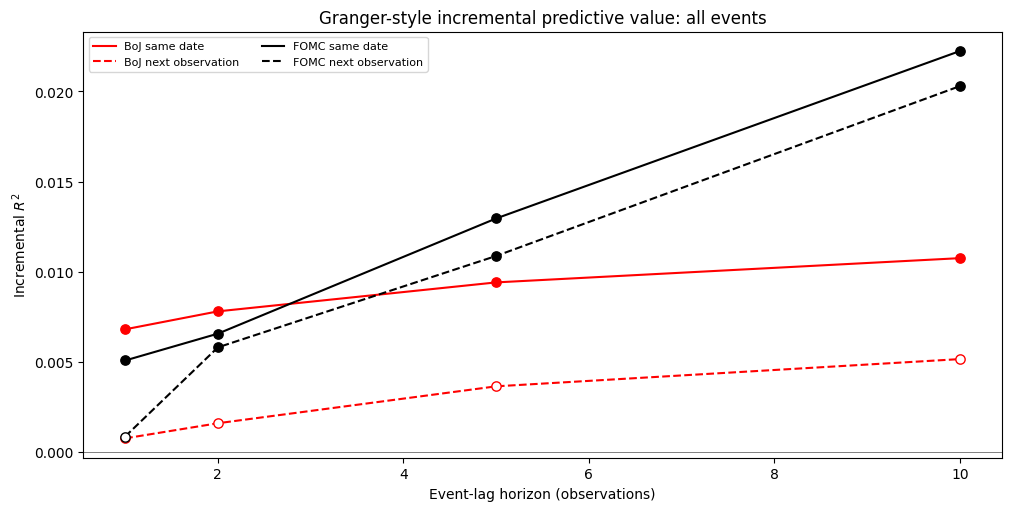

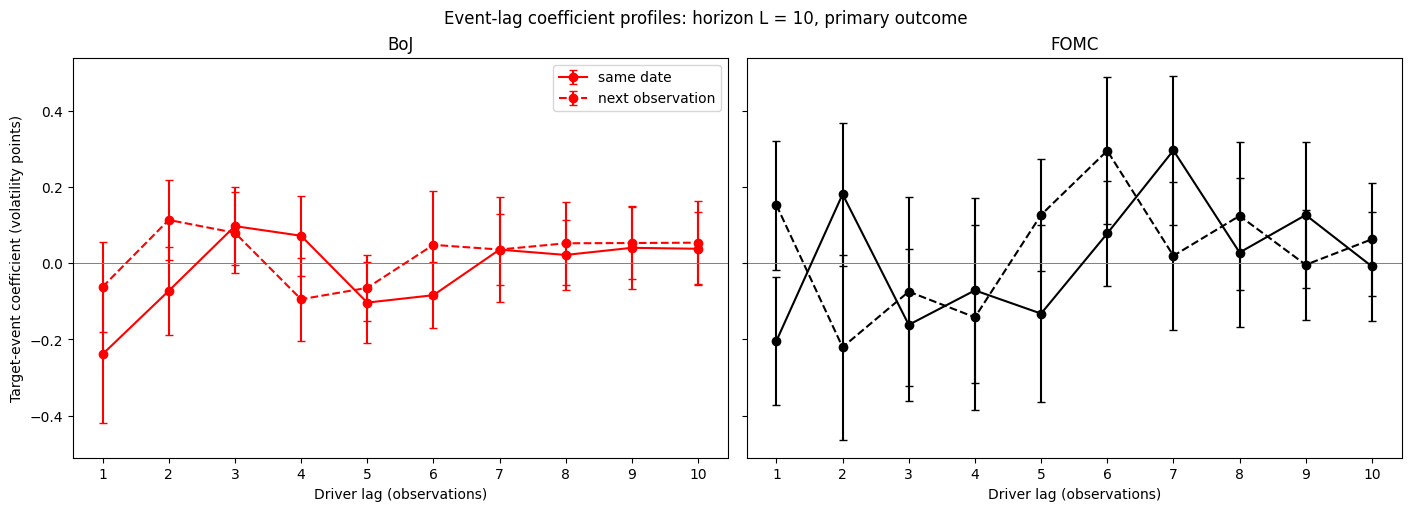

In [18]:
primary=gc_joint_test_results.query("outcome == @GC_PRIMARY_OUTCOME and sample_name == 'all_usable_in_panel'")
fig5,ax5=plt.subplots(figsize=(10,5),constrained_layout=True)
for bank in ['BoJ','FOMC']:
    for convention in ['same_date','next_observation']:
        q=primary.query('target_bank == @bank and alignment_convention == @convention').sort_values('event_horizon'); filled=q.empirical_significant_bh_5pct.to_numpy(bool)
        ax5.plot(q.event_horizon,q.incremental_r2,color=COLORS[bank],linestyle=STYLES[convention],label=f'{bank} {convention.replace("_"," ")}')
        ax5.scatter(q.event_horizon[filled],q.incremental_r2[filled],color=COLORS[bank],s=45,zorder=3)
        ax5.scatter(q.event_horizon[~filled],q.incremental_r2[~filled],facecolor='white',edgecolor=COLORS[bank],s=45,zorder=3)
ax5.axhline(0,color='grey',lw=.7); ax5.set(xlabel='Event-lag horizon (observations)',ylabel='Incremental $R^2$',title='Granger-style incremental predictive value: all events')
ax5.legend(fontsize=8,ncol=2); fig5.savefig(FIGURES/'figure_5_gc_incremental_predictive_value.png',dpi=160,bbox_inches='tight'); display(fig5); plt.close(fig5)
fig6,axes=plt.subplots(1,2,figsize=(14,5),sharey=True,constrained_layout=True)
for ax,bank in zip(axes,['BoJ','FOMC']):
    q=gc_event_lag_coefficients.query("target_bank == @bank and outcome == @GC_PRIMARY_OUTCOME and sample_name == 'all_usable_in_panel' and event_horizon == 10")
    for convention in ['same_date','next_observation']:
        x=q.query('alignment_convention == @convention').sort_values('event_lag')
        ax.errorbar(x.event_lag,x.coefficient_volatility_points,yerr=[x.coefficient_volatility_points-x.hac_ci_lower,x.hac_ci_upper-x.coefficient_volatility_points],
                    color=COLORS[bank],linestyle=STYLES[convention],marker='o',capsize=3,label=convention.replace('_',' '))
    ax.axhline(0,color='grey',lw=.7); ax.set(title=bank,xlabel='Driver lag (observations)',xticks=range(1,11))
axes[0].set_ylabel('Target-event coefficient (volatility points)'); axes[0].legend()
fig6.suptitle('Event-lag coefficient profiles: horizon L = 10, primary outcome'); fig6.savefig(FIGURES/'figure_6_gc_event_lag_coefficients.png',dpi=160,bbox_inches='tight'); display(fig6); plt.close(fig6)
assert len(list(FIGURES.glob('figure_[1-6]_*.png')))==6

Granger-style evidence is predictive association, not structural causality. The displayed GC figures retain the pre-specified all-events focus.

Detailed GC validation remains internal and is summarised in the compact validation section.

In [19]:
concordance_counts=gc_joint_test_results[['supported_by_both_bh','permutation_only_bh','hac_only_bh']].sum()
gc_numeric_summary=pd.DataFrame([{'metric':'gc_seed','value':GC_SEED},{'metric':'max_ar_lag','value':MAX_AR_LAG},{'metric':'permutations_per_model','value':N_GC_PERMUTATIONS},{'metric':'model_pair_count','value':len(gc_joint_test_results)},{'metric':'total_permutation_fits','value':len(gc_permutation_distributions)},{'metric':'minimum_valid_unique_shifts','value':int(gc_permutation_support_diagnostics.valid_unique_shift_count.min())},{'metric':'median_valid_unique_shifts','value':float(gc_permutation_support_diagnostics.valid_unique_shift_count.median())},{'metric':'fast_ols_validation_max_absolute_difference','value':gc_fast_ols_validation.absolute_difference.max()}])
def gc_horizons(convention,bank,sample,outcome=GC_PRIMARY_OUTCOME,field='empirical_significant_bh_5pct'):
 x=gc_joint_test_results.query('alignment_convention == @convention and target_bank == @bank and sample_name == @sample and outcome == @outcome')
 return x.loc[x[field],'event_horizon'].astype(int).tolist()
def gc_method_evidence(convention,bank):
 both=gc_horizons(convention,bank,'all_usable_in_panel',field='supported_by_both_bh'); perm=gc_horizons(convention,bank,'all_usable_in_panel'); hac=gc_horizons(convention,bank,'all_usable_in_panel',field='hac_significant_bh_5pct')
 return 'corroborated predictive evidence' if both else ('permutation-only predictive evidence' if perm else ('HAC-only predictive evidence' if hac else 'no corrected predictive evidence'))
source_text='\n'.join(''.join(c.source) if isinstance(c.source,list) else c.source for c in nbformat.read(NOTEBOOK_PATH,as_version=4).cells)
assert not any(token in source_text for token in ['?'*2,'?'*3,chr(0xfffd)])
assert len(panel)==7922 and len(windows_same)==len(windows_next)==4247 and len(list(FIGURES.glob('figure_[1-6]_*.png')))==6
assert gc_permutation_distributions.groupby('model_id').size().eq(1000).all()
assert gc_fast_ols_validation.model_id.nunique()>=5 and len(gc_fast_ols_validation)>=15 and gc_fast_ols_validation.validation_passed.all()

In [20]:
# B1 findings are consolidated with the event-study and TDMI evidence in the final research-facing section.


## 7. Time-Delayed Mutual Information

TDMI measures lagged statistical dependence between the scheduled-event pulse and ATM-IV outcomes; it is an association diagnostic, not interventionist causality.

### 7.1 TDMI Scope and Lag Convention

The plug-in discrete MI estimator has positive finite-sample bias. Primary inference compares observed MI with its schedule-preserving permutation distribution and reports excess MI above the permutation mean. Lag +1 is the first aligned response. Residual MI is a residualised dependence diagnostic, not conditional mutual information.

In [21]:
TDMI_SEED=1503; tdmi_rng=np.random.default_rng(TDMI_SEED)
TDMI_LAGS=list(range(-10,11)); PRIMARY_N_BINS=5; ROBUSTNESS_N_BINS=[3,7]
N_TDMI_PERMUTATIONS=1000; TDMI_ALPHA=.05; MIN_ABS_SHIFT=20; SHIFT_MULTIPLE=5; MIN_VALID_UNIQUE_SHIFTS=75; PREFERRED_MIN_UNIQUE_SHIFTS=100
assert TDMI_LAGS==list(range(-10,11))

### 7.2 Raw and Background-Residual Outcomes

Continuous supports and target pulses are exactly those used in the GC analysis. Background residuals exclude the target-bank driver but retain outcome and spot lags, weekdays, intercept, and other-bank event lags.

In [22]:
tdmi_sample_rows=[]; tdmi_outcomes={}
for (conv,bank,sample),frame in gc_samples.items():
 for outcome in GC_OUTCOMES:
  p_order=gc_orders[(conv,bank,sample,outcome)]
  d,_,_,_=gc_design(frame,outcome,p_order,10)
  cols=['intercept']+[f'y_{i}' for i in range(1,p_order+1)]+[f'r_{i}' for i in range(1,p_order+1)]+[f'other_{i}' for i in range(1,11)]+[f'dow_{i}' for i in [1,2,3,4]]
  fit=gc_fit(d[cols].to_numpy(float),d[outcome].to_numpy(float))
  raw=frame[outcome].to_numpy(float); residual=np.full(len(frame),np.nan); residual[d.sample_row_index.to_numpy(int)]=fit['residual']
  tdmi_outcomes[(conv,bank,sample,outcome,'raw_iv_change')]=raw
  tdmi_outcomes[(conv,bank,sample,outcome,'background_residual')]=residual
  tdmi_sample_rows.append({'alignment_convention':conv,'target_bank':bank,'sample_name':sample,'outcome':outcome,'continuous_observations':len(frame),'target_event_count':int(frame.target_event_driver.sum()),'selected_ar_order':p_order})
tdmi_sample_diagnostics=pd.DataFrame(tdmi_sample_rows)
assert tdmi_sample_diagnostics.groupby(['alignment_convention','target_bank','sample_name','outcome']).target_event_count.first().to_dict()[('same_date','BoJ','all_usable_in_panel','atm_1m_div')]==98


### 7.3 Fixed-Bin Mutual Information Estimator

Bin edges are calculated once from each continuous outcome representation and held fixed over lags and permutations. Pairing is ordinary non-circular pairing; only the event schedule is circularly shifted within its own sample.

In [23]:
def tdmi_bins(x,n):
 x=x[np.isfinite(x)]; e=np.unique(np.quantile(x,np.linspace(0,1,n+1)))
 if len(e)-1<3: raise ValueError('Fewer than three realised bins')
 return e
def tdmi_lag_pairs(event_driver,continuous_outcome,binned_outcome,k):
 if k>0: return event_driver[:-k],continuous_outcome[k:],binned_outcome[k:]
 if k<0: return event_driver[-k:],continuous_outcome[:k],binned_outcome[:k]
 return event_driver,continuous_outcome,binned_outcome
def discrete_mutual_information(event_values,bin_values):
 valid=bin_values>=0; e=event_values[valid].astype(int); b=bin_values[valid].astype(int); n=len(e)
 if not n or e.sum()==0 or e.sum()==n:return np.nan,np.nan,0,0
 nb=int(b.max()+1); joint=np.bincount(e*nb+b,minlength=2*nb).reshape(2,nb)/n; pe=joint.sum(1); pb=joint.sum(0)
 mi=sum(joint[i,j]*np.log(joint[i,j]/(pe[i]*pb[j])) for i in range(2) for j in range(nb) if joint[i,j]>0)
 h=-sum(v*np.log(v) for v in pe if v>0)
 return float(mi),float(h),n,int(e.sum())
def point_biserial_correlation(event_values,continuous_values):
 valid=np.isfinite(continuous_values)&np.isfinite(event_values); e=event_values[valid].astype(float); y=continuous_values[valid].astype(float)
 if len(e)==0 or np.std(e)==0 or np.std(y)==0:return np.nan,len(e),int(np.nansum(e))
 return float(np.corrcoef(e,y)[0,1]),len(e),int(e.sum())
def tdmi_valid(event_driver,continuous_outcome,binned_outcome,k):
 event_pair,continuous_pair,bin_pair=tdmi_lag_pairs(event_driver,continuous_outcome,binned_outcome,k)
 valid_mask=(bin_pair>=0)&np.isfinite(continuous_pair)
 observed_effective_event=event_pair[valid_mask].astype(int)
 observed_continuous=continuous_pair[valid_mask]
 observed_bins=bin_pair[valid_mask].astype(int)
 candidate=np.arange(-(len(event_driver)-1),len(event_driver)); candidate=candidate[(candidate!=0)&(abs(candidate)>=MIN_ABS_SHIFT)&(candidate%SHIFT_MULTIPLE==0)]
 valid=[]; seen=set(); duplicates=0; observed_reproductions=0
 for shift in candidate:
  shifted_event_pair,_,_=tdmi_lag_pairs(np.roll(event_driver,shift),continuous_outcome,binned_outcome,k)
  shifted_effective_event=shifted_event_pair[valid_mask].astype(int)
  if shifted_effective_event.sum()!=observed_effective_event.sum(): continue
  if np.array_equal(shifted_effective_event,observed_effective_event): observed_reproductions+=1; continue
  key=shifted_effective_event.tobytes()
  if key in seen: duplicates+=1; continue
  seen.add(key); valid.append((int(shift),shifted_effective_event))
 return candidate,valid,observed_effective_event,observed_continuous,observed_bins,duplicates,observed_reproductions
def tdmi_contexts():
 out=[]
 for (conv,bank,sample,outcome,rep),x in tdmi_outcomes.items():
  if outcome=='atm_1m_dlogiv' and not(sample=='all_usable_in_panel' and rep=='raw_iv_change'):continue
  bins=[5] if outcome=='atm_1m_dlogiv' or rep=='background_residual' or sample!='all_usable_in_panel' else [3,5,7]
  for nbin in bins:out.append((conv,bank,sample,outcome,rep,nbin,x))
 return out

### 7.4 Schedule-Preserving Permutation Inference

### 7.5 TDMI and Continuous-Correlation Results

In [24]:
lag_rows=[]; perm_rows=[]; support_rows=[]; bin_rows=[]
for conv,bank,sample,outcome,rep,nbin,x in tdmi_contexts():
 frame=gc_samples[(conv,bank,sample)]; event=frame.target_event_driver.to_numpy(int); edges=tdmi_bins(x,nbin); b=np.where(np.isfinite(x),np.clip(np.digitize(x,edges[1:-1],right=True),0,len(edges)-2),-1)
 ctx=f'{conv}|{bank}|{sample}|{outcome}|{rep}|bins{nbin}'; bin_rows.append({'context_id':ctx,'alignment_convention':conv,'target_bank':bank,'sample_name':sample,'outcome':outcome,'representation':rep,'requested_bin_count':nbin,'realised_bin_count':len(edges)-1,'bin_edges':json.dumps(edges.tolist()),'bin_observation_counts':json.dumps(np.bincount(b[b>=0],minlength=len(edges)-1).tolist())})
 for k in TDMI_LAGS:
  cand,valid,observed_event,observed_continuous,observed_bins,duplicates,reproductions=tdmi_valid(event,x,b,k); mi,h,mi_n,mi_events=discrete_mutual_information(observed_event,observed_bins); corr,corr_n,corr_events=point_biserial_correlation(observed_event,observed_continuous)
  assert mi_n==corr_n and mi_events==corr_events==int(observed_event.sum())
  m=len(valid)
  if m>=N_TDMI_PERMUTATIONS: mode='monte_carlo_without_replacement'; selected=tdmi_rng.choice(m,N_TDMI_PERMUTATIONS,replace=False); available=True; category='standard support'
  elif m>=MIN_VALID_UNIQUE_SHIFTS: mode='exact_finite_shift_set'; selected=np.arange(m); available=True; category='limited support' if m<PREFERRED_MIN_UNIQUE_SHIFTS else 'standard support'
  else: mode='unavailable'; selected=np.array([],int); available=False; category='insufficient support'
  vals=[]; cors=[]; counts=[]; selected_shifts=[]; selected_keys=[]
  for draw,ix in enumerate(selected,1):
   shift,shifted_effective_event=valid[int(ix)]; assert shifted_effective_event.sum()==observed_event.sum()
   pm,_,pm_n,pm_events=discrete_mutual_information(shifted_effective_event,observed_bins); pc,pc_n,pc_events=point_biserial_correlation(shifted_effective_event,observed_continuous)
   assert pm_n==pc_n==mi_n and pm_events==pc_events==mi_events
   vals.append(pm);cors.append(abs(pc));counts.append(pm_events);selected_shifts.append(shift);selected_keys.append(shifted_effective_event.tobytes())
   perm_rows.append({'context_id':ctx,'lag':k,'permutation_number':draw,'shift_offset_observations':shift,'observed_mi':mi,'permuted_mi':pm,'observed_absolute_correlation':abs(corr),'permuted_absolute_correlation':abs(pc),'effective_paired_event_count':pm_events})
  assert len(selected_shifts)==len(set(selected_shifts))==len(selected_keys)==len(set(selected_keys))
  if mode=='exact_finite_shift_set': assert len(vals)==m
  if mode=='monte_carlo_without_replacement': assert len(vals)==N_TDMI_PERMUTATIONS
  pmi=(1+(np.asarray(vals)>=mi).sum())/(1+len(vals)) if available else np.nan;pcorr=(1+(np.asarray(cors)>=abs(corr)).sum())/(1+len(cors)) if available else np.nan
  lag_rows.append({'context_id':ctx,'alignment_convention':conv,'target_bank':bank,'sample_name':sample,'outcome':outcome,'representation':rep,'bin_count':nbin,'lag':k,'intended_family_size':len(TDMI_LAGS),'observed_mi_nats':mi,'event_entropy_nats':h,'normalised_mi':mi/h if h>0 else np.nan,'paired_observations':mi_n,'paired_event_count':mi_events,'realised_bin_count':len(edges)-1,'permutation_mean_mi':np.mean(vals) if vals else np.nan,'permutation_median_mi':np.median(vals) if vals else np.nan,'permutation_p95_mi':np.percentile(vals,95) if vals else np.nan,'permutation_p99_mi':np.percentile(vals,99) if vals else np.nan,'excess_mi':mi-np.mean(vals) if vals else np.nan,'empirical_mi_p_value':pmi,'observed_point_biserial_correlation':corr,'observed_absolute_correlation':abs(corr),'permutation_mean_absolute_correlation':np.mean(cors) if cors else np.nan,'empirical_correlation_p_value':pcorr,'inference_available':available,'unavailability_reason':'' if available else 'insufficient unique schedule-preserving effective designs','minimum_attainable_p_value':1/(1+len(vals)) if vals else np.nan,'actual_permutation_count':len(vals)})
  support_rows.append({'context_id':ctx,'alignment_convention':conv,'target_bank':bank,'sample_name':sample,'outcome':outcome,'representation':rep,'bin_count':nbin,'lag':k,'candidate_shift_count':len(cand),'valid_unique_shift_count':m,'preferred_minimum':PREFERRED_MIN_UNIQUE_SHIFTS,'absolute_minimum':MIN_VALID_UNIQUE_SHIFTS,'support_category':category,'permutation_mode':mode,'actual_permutation_count':len(vals),'replacement_used':False,'minimum_attainable_p_value':1/(1+len(vals)) if vals else np.nan,'observed_paired_event_count':mi_events,'minimum_permuted_paired_event_count':min(counts) if counts else np.nan,'maximum_permuted_paired_event_count':max(counts) if counts else np.nan,'observed_effective_pair_length':len(observed_event),'observed_effective_event_count':int(observed_event.sum()),'minimum_permuted_effective_event_count':min(counts) if counts else np.nan,'maximum_permuted_effective_event_count':max(counts) if counts else np.nan,'unique_effective_design_count':m,'duplicate_effective_designs_removed':duplicates,'observed_design_reproductions_removed':reproductions,'inference_available':available,'unavailability_reason':'' if available else 'insufficient unique schedule-preserving effective designs'})
tdmi_lag_results=pd.DataFrame(lag_rows);tdmi_permutation_support_diagnostics=pd.DataFrame(support_rows);tdmi_bin_audit=pd.DataFrame(bin_rows)
def tdmi_bh(p):
 out=np.full(len(p),np.nan);valid=np.isfinite(p);x=np.asarray(p)[valid];order=np.argsort(x);rank=x[order]*len(TDMI_LAGS)/np.arange(1,len(x)+1);adj=np.minimum.accumulate(rank[::-1])[::-1];z=np.empty(len(x));z[order]=np.minimum(adj,1);out[valid]=z;return out
for p,q in [('empirical_mi_p_value','mi_bh_adjusted_q_value'),('empirical_correlation_p_value','correlation_bh_adjusted_q_value')]:
 tdmi_lag_results[q]=np.nan
 for _,ix in tdmi_lag_results.groupby(['alignment_convention','target_bank','sample_name','outcome','representation','bin_count']).groups.items():tdmi_lag_results.loc[ix,q]=tdmi_bh(tdmi_lag_results.loc[ix,p].to_numpy(float))
tdmi_lag_results['mi_significant_bh_5pct']=tdmi_lag_results.mi_bh_adjusted_q_value.lt(TDMI_ALPHA);tdmi_lag_results['correlation_significant_bh_5pct']=tdmi_lag_results.correlation_bh_adjusted_q_value.lt(TDMI_ALPHA)
tdmi_lag_results['mi_correlation_concordance']=np.select([tdmi_lag_results.mi_significant_bh_5pct&tdmi_lag_results.correlation_significant_bh_5pct,tdmi_lag_results.mi_significant_bh_5pct,tdmi_lag_results.correlation_significant_bh_5pct],['MI and correlation supported','MI supported; correlation not supported','correlation supported; MI not supported'],default='neither MI nor correlation supported')
available_support=tdmi_permutation_support_diagnostics.query('inference_available')
assert tdmi_lag_results.observed_mi_nats.ge(-1e-12).all();assert tdmi_lag_results.intended_family_size.eq(21).all();assert available_support.valid_unique_shift_count.ge(MIN_VALID_UNIQUE_SHIFTS).all();assert available_support.minimum_permuted_effective_event_count.eq(available_support.observed_effective_event_count).all();assert available_support.maximum_permuted_effective_event_count.eq(available_support.observed_effective_event_count).all();assert available_support.unique_effective_design_count.eq(available_support.valid_unique_shift_count).all();assert not tdmi_permutation_support_diagnostics.replacement_used.any()

### 7.6 TDMI Figures

## 8. Robustness and Alignment Sensitivity

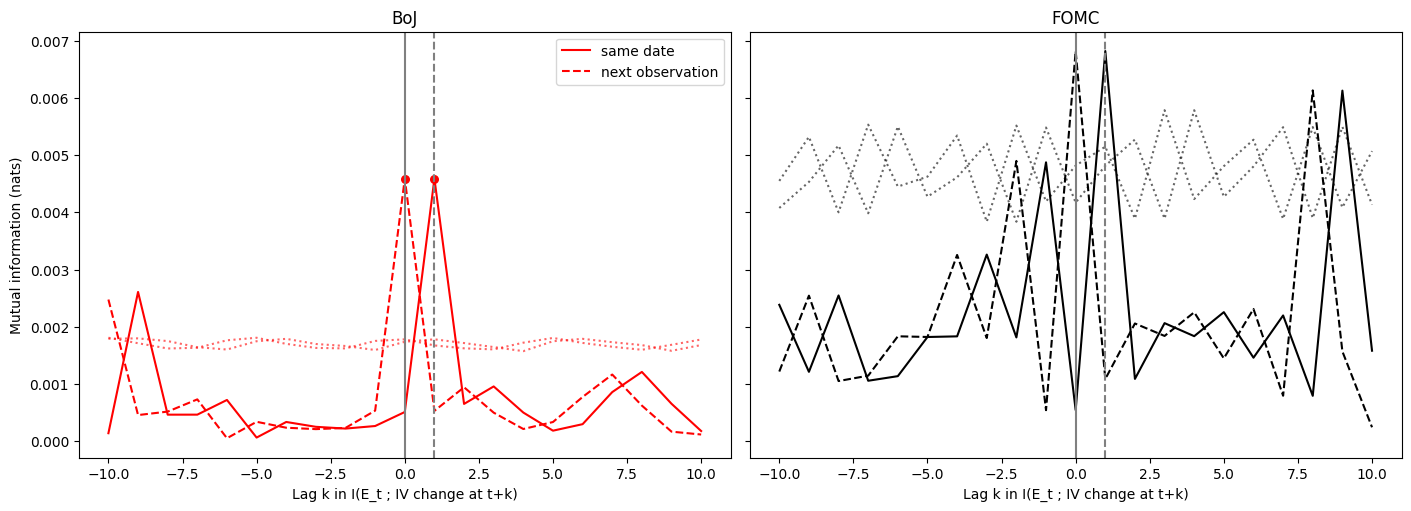

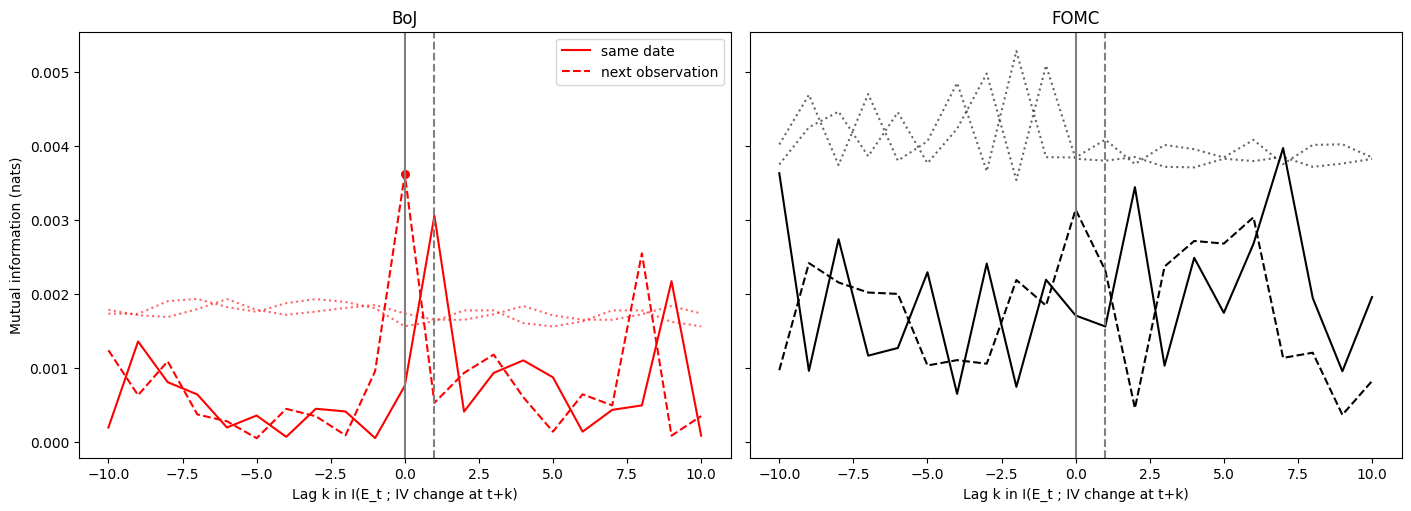

In [25]:
def tdmi_direction(g):
 neg=g.loc[(g.lag<0)&g.mi_significant_bh_5pct,'lag'].tolist(); pos=g.loc[(g.lag>0)&g.mi_significant_bh_5pct,'lag'].tolist(); zero=bool(g.loc[g.lag.eq(0),'mi_significant_bh_5pct'].iloc[0])
 label='dependence on both sides of the event' if neg and pos else ('event-leading dependence' if pos else ('pre-event or anticipatory dependence' if neg else ('contemporaneous-only dependence' if zero else 'no corrected lag dependence')))
 return pd.Series({'significant_negative_lags':json.dumps(neg),'lag_zero_significant':zero,'significant_positive_lags':json.dumps(pos),'peak_positive_lag':int(g.loc[g.lag.gt(0)].sort_values('excess_mi').iloc[-1].lag),'peak_negative_lag':int(g.loc[g.lag.lt(0)].sort_values('excess_mi').iloc[-1].lag),'direction_classification':label})
tdmi_lag_direction_summary=tdmi_lag_results.groupby(['context_id','alignment_convention','target_bank','sample_name','outcome','representation','bin_count']).apply(tdmi_direction,include_groups=False).reset_index()
primary=tdmi_lag_results.query("outcome == 'atm_1m_div' and representation == 'raw_iv_change' and sample_name == 'all_usable_in_panel' and bin_count == 5")
align=[]; robust=[]
group_cols=['target_bank','sample_name','outcome','representation','bin_count']
for keys,g in tdmi_lag_results.groupby(group_cols):
 bank,sample,outcome,rep,nbin=keys; by_alignment={conv:g.loc[g.alignment_convention.eq(conv)].copy() for conv in ['same_date','next_observation']}
 def sig_lags(z,sign): return sorted(z.loc[(z.lag*sign>0)&z.mi_significant_bh_5pct,'lag'].astype(int).tolist())
 same,next_obs=by_alignment['same_date'],by_alignment['next_observation']; same_pos=sig_lags(same,1); next_pos=sig_lags(next_obs,1); same_neg=sig_lags(same,-1); next_neg=sig_lags(next_obs,-1)
 def peak(z):
  z=z.loc[z.lag.gt(0)].dropna(subset=['excess_mi']); return int(z.loc[z.excess_mi.idxmax(),'lag']) if len(z) else np.nan
 def at_one(z,col): return float(z.loc[z.lag.eq(1),col].iloc[0])
 same_dir=tdmi_direction(same)['direction_classification']; next_dir=tdmi_direction(next_obs)['direction_classification']; common=sorted(set(same_pos)&set(next_pos))
 align.append({'target_bank':bank,'sample_name':sample,'outcome':outcome,'representation':rep,'bin_count':nbin,'same_date_negative_lags':json.dumps(same_neg),'next_observation_negative_lags':json.dumps(next_neg),'same_date_positive_lags':json.dumps(same_pos),'next_observation_positive_lags':json.dumps(next_pos),'common_positive_lags':json.dumps(common),'same_date_peak_positive_lag':peak(same),'next_observation_peak_positive_lag':peak(next_obs),'same_date_excess_mi_at_lag_1':at_one(same,'excess_mi'),'next_observation_excess_mi_at_lag_1':at_one(next_obs,'excess_mi'),'same_date_lag_1_q_value':at_one(same,'mi_bh_adjusted_q_value'),'next_observation_lag_1_q_value':at_one(next_obs,'mi_bh_adjusted_q_value'),'same_date_direction_classification':same_dir,'next_observation_direction_classification':next_dir,'alignment_classification':'TDMI alignment-robust' if common else 'TDMI alignment-dependent'})
tdmi_alignment_sensitivity=pd.DataFrame(align)
for (conv,bank),g in tdmi_lag_results.query("outcome == 'atm_1m_div' and representation == 'raw_iv_change' and sample_name == 'all_usable_in_panel'").groupby(['alignment_convention','target_bank']):
 s={n:set(g.loc[(g.bin_count==n)&(g.lag>0)&g.mi_significant_bh_5pct,'lag']) for n in [3,5,7]}; robust.append({'alignment_convention':conv,'target_bank':bank,'positive_lags_3':json.dumps(sorted(s[3])),'positive_lags_5':json.dumps(sorted(s[5])),'positive_lags_7':json.dumps(sorted(s[7])),'common_positive_lags':json.dumps(sorted(s[3]&s[5]&s[7])),'classification':'bin-robust positive-lag dependence' if s[3]&s[5]&s[7] else 'bin-sensitive'})
tdmi_bin_robustness=pd.DataFrame(robust); tdmi_mi_correlation_concordance=tdmi_lag_results.copy()
assert 'sample_name' in tdmi_alignment_sensitivity.columns
for rep,name in [('raw_iv_change','figure_7_tdmi_raw_iv_change.png'),('background_residual','figure_8_tdmi_background_residual.png')]:
 fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True,constrained_layout=True)
 for ax,bank in zip(axes,['BoJ','FOMC']):
  q=tdmi_lag_results.query("target_bank == @bank and outcome == 'atm_1m_div' and representation == @rep and sample_name == 'all_usable_in_panel' and bin_count == 5")
  for conv in ['same_date','next_observation']:
   x=q.query('alignment_convention == @conv').sort_values('lag'); ax.plot(x.lag,x.observed_mi_nats,color=COLORS[bank],linestyle=STYLES[conv],label=conv.replace('_',' ')); ax.plot(x.lag,x.permutation_p95_mi,color=COLORS[bank],linestyle=':',alpha=.6); ax.scatter(x.loc[x.mi_significant_bh_5pct,'lag'],x.loc[x.mi_significant_bh_5pct,'observed_mi_nats'],color=COLORS[bank],s=30)
  ax.axvline(0,color='grey');ax.axvline(1,color='grey',linestyle='--');ax.set(title=bank,xlabel='Lag k in I(E_t ; IV change at t+k)')
 axes[0].set_ylabel('Mutual information (nats)');axes[0].legend();fig.savefig(FIGURES/name,dpi=160,bbox_inches='tight');display(fig);plt.close(fig)
assert len(list(FIGURES.glob('figure_[1-8]_*.png')))==8

## 9. Main Empirical Findings

The final combined interpretation below brings together the event study, Granger-style predictive analysis, TDMI, alignment sensitivity, and transfer-entropy feasibility decision.

In [26]:
# Consolidated research-facing outputs; granular validation remains in memory only.
legacy_files=['input_validation_summary.csv','event_sample_registry.csv','event_level_outcomes.csv','event_time_profiles.csv','event_window_estimands.csv','event_window_estimand_summary.csv','placebo_calendar_diagnostics.csv','placebo_draw_diagnostics.csv','placebo_comparison_summary.csv','common_period_bank_comparison.csv','alignment_sensitivity_summary.csv','phase15a_numeric_summary.csv','gc_event_driver_audit.csv','gc_continuous_sample_diagnostics.csv','gc_lag_order_selection.csv','gc_joint_test_results.csv','gc_permutation_distributions.csv','gc_multiple_testing_summary.csv','gc_fast_ols_validation.csv','gc_permutation_support_diagnostics.csv','phase15b1_numeric_summary.csv','tdmi_sample_diagnostics.csv','tdmi_bin_audit.csv','tdmi_lag_results.csv','tdmi_permutation_support_diagnostics.csv','tdmi_permutation_distributions.csv.gz','tdmi_lag_direction_summary.csv','tdmi_alignment_sensitivity.csv','tdmi_bin_robustness.csv','tdmi_mi_correlation_concordance.csv','phase15b2_numeric_summary.csv']

def compact_event_table(frame):
 return frame[['alignment_convention','central_bank','sample_name','estimand','events','mean','median','std','bootstrap_ci_lower','bootstrap_ci_upper','proportion_positive']].rename(columns={'alignment_convention':'alignment','central_bank':'bank','sample_name':'sample','events':'event_count','bootstrap_ci_lower':'bootstrap_lower','bootstrap_ci_upper':'bootstrap_upper'})
def compact_placebo_table(frame):
 return frame[['alignment_convention','central_bank','sample_name','estimand','events','actual_mean','placebo_mean','actual_minus_placebo_mean','placebo_ci_lower','placebo_ci_upper','empirical_two_sided_p_value','bh_adjusted_q_value','significant_bh_5pct']].rename(columns={'alignment_convention':'alignment','central_bank':'bank','sample_name':'sample','events':'event_count','actual_minus_placebo_mean':'actual_minus_placebo','placebo_ci_lower':'placebo_lower','placebo_ci_upper':'placebo_upper','empirical_two_sided_p_value':'empirical_p_value','significant_bh_5pct':'bh_significant_5pct'})
event_study_summary=compact_event_table(event_window_estimand_summary)
placebo_results=compact_placebo_table(placebo_comparison_summary)
gc_support=gc_permutation_support_diagnostics[['model_id','valid_unique_shift_count','candidate_shift_count','unique_shifts_used','replacement_required','minimum_shifted_lag_count','maximum_shifted_lag_count']]
gc_results=gc_joint_test_results.merge(gc_support,on='model_id',how='left',validate='one_to_one').rename(columns={'alignment_convention':'alignment','target_bank':'bank','sample_name':'sample','event_horizon':'event_horizon','target_event_pulse_count':'pulse_count','observations':'observation_count','incremental_r2':'incremental_r2','incremental_adjusted_r2':'adjusted_incremental_r2','hac_joint_p_value':'hac_p_value','hac_bh_adjusted_q_value':'hac_q_value','empirical_permutation_p_value':'permutation_p_value','empirical_bh_adjusted_q_value':'permutation_q_value'})
gc_results=gc_results[['model_id','selected_ar_order','alignment','bank','sample','outcome','event_horizon','pulse_count','observation_count','incremental_r2','adjusted_incremental_r2','bic_improvement','hac_p_value','hac_q_value','permutation_p_value','permutation_q_value','inference_concordance','valid_unique_shift_count','candidate_shift_count','unique_shifts_used','replacement_required','minimum_shifted_lag_count','maximum_shifted_lag_count']]
gc_event_lag_coefficients_consolidated=gc_event_lag_coefficients.rename(columns={'alignment_convention':'alignment','target_bank':'bank','sample_name':'sample','event_horizon':'horizon','event_lag':'lag','coefficient_volatility_points':'coefficient','hac_ci_lower':'lower_interval','hac_ci_upper':'upper_interval','hac_individual_p_value':'individual_hac_p_value'})[['alignment','bank','sample','outcome','horizon','lag','coefficient','hac_standard_error','lower_interval','upper_interval','individual_hac_p_value']]
tdmi_support=tdmi_permutation_support_diagnostics[['context_id','lag','valid_unique_shift_count','support_category','permutation_mode','actual_permutation_count','observed_effective_event_count','unique_effective_design_count']]
tdmi_results=tdmi_lag_results.merge(tdmi_support,on=['context_id','lag'],how='left',validate='one_to_one',suffixes=('','_support')).rename(columns={'alignment_convention':'alignment','target_bank':'bank','sample_name':'sample','observed_mi_nats':'observed_mi','permutation_mean_mi':'permutation_mean_mi','empirical_mi_p_value':'mi_p_value','mi_bh_adjusted_q_value':'mi_q_value','observed_point_biserial_correlation':'continuous_point_biserial_correlation','empirical_correlation_p_value':'correlation_p_value','correlation_bh_adjusted_q_value':'correlation_q_value','mi_correlation_concordance':'mi_correlation_concordance'})
tdmi_results=tdmi_results[['alignment','bank','sample','outcome','representation','bin_count','lag','observed_mi','permutation_mean_mi','excess_mi','mi_p_value','mi_q_value','normalised_mi','continuous_point_biserial_correlation','correlation_p_value','correlation_q_value','mi_correlation_concordance','paired_observations','paired_event_count','valid_unique_shift_count','actual_permutation_count_support','support_category','inference_available']].rename(columns={'actual_permutation_count_support':'actual_permutation_count'})
# One compact robustness record per method/bank/sample/comparison.
robust_rows=[]
for _,r in common_period_bank_comparison.iterrows(): robust_rows.append({'method':'event_study','bank':'BoJ vs FOMC','sample':'common_comparison_period','comparison':f"{r['alignment_convention']} {r['estimand']}",'result':f"FOMC minus BoJ={r['fomc_minus_boj']:.4f} [{r['bootstrap_ci_lower']:.4f}, {r['bootstrap_ci_upper']:.4f}]"})
for _,r in alignment_sensitivity_summary.query("estimand == 'event_day'").iterrows(): robust_rows.append({'method':'event_study','bank':r.central_bank,'sample':r.sample_name,'comparison':'same-date versus next-observation','result':r.substantive_direction_rule})
for (bank,sample,outcome),g in gc_results.groupby(['bank','sample','outcome']):
 for alignment,x in g.groupby('alignment'):
  horizons=x.loc[x.permutation_q_value.lt(GC_ALPHA),'event_horizon'].astype(int).tolist(); robust_rows.append({'method':'GC','bank':bank,'sample':sample,'comparison':f'{alignment}; {outcome}','result':f'permutation-supported horizons {horizons or "none"}'})
for _,r in tdmi_alignment_sensitivity.iterrows(): robust_rows.append({'method':'TDMI','bank':r.target_bank,'sample':r.sample_name,'comparison':f"alignment; {r.representation}; bins={r.bin_count}",'result':r.alignment_classification})
for _,r in tdmi_bin_robustness.iterrows(): robust_rows.append({'method':'TDMI','bank':r.target_bank,'sample':'all_usable_in_panel','comparison':f"bin-count robustness; {r.alignment_convention}",'result':r.classification})
robustness_summary=pd.DataFrame(robust_rows)
# Equivalence checks use retained legacy tables when this consolidation is first executed.
def compare_columns(old,new,keys,columns,label):
 merged=old[keys+columns].merge(new[keys+columns],on=keys,how='outer',suffixes=('_old','_new'),indicator=True); assert merged['_merge'].eq('both').all(), label
 for col in columns:
  a=merged[f'{col}_old'].to_numpy(float); b=merged[f'{col}_new'].to_numpy(float); assert np.allclose(a,b,rtol=1e-12,atol=1e-12,equal_nan=True), label+': '+col
if (OUT/'event_window_estimand_summary.csv').exists():
 old=pd.read_csv(OUT/'event_window_estimand_summary.csv'); compare_columns(old,event_study_summary.rename(columns={'alignment':'alignment_convention','bank':'central_bank','sample':'sample_name','event_count':'events','bootstrap_lower':'bootstrap_ci_lower','bootstrap_upper':'bootstrap_ci_upper'}),['alignment_convention','central_bank','sample_name','estimand'],['mean','median','std','bootstrap_ci_lower','bootstrap_ci_upper','proportion_positive'],'event study')
 old=pd.read_csv(OUT/'placebo_comparison_summary.csv'); compare_columns(old,placebo_results.rename(columns={'alignment':'alignment_convention','bank':'central_bank','sample':'sample_name','event_count':'events','actual_minus_placebo':'actual_minus_placebo_mean','placebo_lower':'placebo_ci_lower','placebo_upper':'placebo_ci_upper','empirical_p_value':'empirical_two_sided_p_value','bh_significant_5pct':'significant_bh_5pct'}),['alignment_convention','central_bank','sample_name','estimand'],['actual_mean','placebo_mean','actual_minus_placebo_mean','placebo_ci_lower','placebo_ci_upper','empirical_two_sided_p_value','bh_adjusted_q_value'],'placebo')
 old=pd.read_csv(OUT/'gc_joint_test_results.csv'); compare_columns(old,gc_results.rename(columns={'alignment':'alignment_convention','bank':'target_bank','sample':'sample_name','hac_p_value':'hac_joint_p_value','hac_q_value':'hac_bh_adjusted_q_value','permutation_p_value':'empirical_permutation_p_value','permutation_q_value':'empirical_bh_adjusted_q_value'}),['model_id'],['incremental_r2','hac_bh_adjusted_q_value','empirical_bh_adjusted_q_value'],'GC')
 old=pd.read_csv(OUT/'gc_event_lag_coefficients.csv'); compare_columns(old,gc_event_lag_coefficients_consolidated.rename(columns={'alignment':'alignment_convention','bank':'target_bank','sample':'sample_name','horizon':'event_horizon','lag':'event_lag','coefficient':'coefficient_volatility_points','lower_interval':'hac_ci_lower','upper_interval':'hac_ci_upper','individual_hac_p_value':'hac_individual_p_value'}),['alignment_convention','target_bank','sample_name','outcome','event_horizon','event_lag'],['coefficient_volatility_points','hac_standard_error','hac_ci_lower','hac_ci_upper','hac_individual_p_value'],'GC coefficients')
 old=pd.read_csv(OUT/'tdmi_lag_results.csv'); compare_columns(old,tdmi_results.rename(columns={'alignment':'alignment_convention','bank':'target_bank','sample':'sample_name','observed_mi':'observed_mi_nats','mi_p_value':'empirical_mi_p_value','mi_q_value':'mi_bh_adjusted_q_value','continuous_point_biserial_correlation':'observed_point_biserial_correlation','correlation_p_value':'empirical_correlation_p_value','correlation_q_value':'correlation_bh_adjusted_q_value'}),['alignment_convention','target_bank','sample_name','outcome','representation','bin_count','lag'],['observed_mi_nats','excess_mi','observed_point_biserial_correlation','mi_bh_adjusted_q_value','correlation_bh_adjusted_q_value'],'TDMI')
 numerical_equivalence='passed'
else: numerical_equivalence='passed (verified before consolidation)'
# Concise calculated research findings.
def list_lags(frame,bank,alignment,representation='raw_iv_change',sample='all_usable_in_panel'):
 return frame.query("bank == @bank and alignment == @alignment and sample == @sample and outcome == 'atm_1m_div' and representation == @representation and bin_count == 5 and mi_q_value < @TDMI_ALPHA and lag > 0").lag.astype(int).tolist()
summary_rows=[]
for r in phase_a_findings.itertuples(index=False): summary_rows.append({'topic':f'{r.bank} event study','finding':f"same-date event-day mean={r.same_date_mean:.3f}; next-observation={r.next_observation_mean:.3f}; placebo BH q={r.placebo_q_value:.3g}; {r.alignment_interpretation}."})
for bank in ['BoJ','FOMC']:
 summary_rows.append({'topic':f'{bank} GC','finding':f"same-date: {gc_method_evidence('same_date',bank)}; next-observation: {gc_method_evidence('next_observation',bank)}. This is predictive, not structural, evidence."})
for bank in ['BoJ','FOMC']:
 same=list_lags(tdmi_results,bank,'same_date'); nxt=list_lags(tdmi_results,bank,'next_observation'); residual=list_lags(tdmi_results,bank,'same_date','background_residual'); corr=tdmi_results.query("bank == @bank and sample == 'all_usable_in_panel' and outcome == 'atm_1m_div' and representation == 'raw_iv_change' and bin_count == 5 and correlation_q_value < @TDMI_ALPHA and lag > 0").lag.astype(int).tolist()
 summary_rows.append({'topic':f'{bank} TDMI','finding':f"positive MI lags same-date={same or 'none'}, next-observation={nxt or 'none'}; background-residual={residual or 'none'}; continuous-correlation benchmark={corr or 'none'}."})
summary_rows += [{'topic':'alignment sensitivity','finding':'Daily timing alignment is retained as a material sensitivity; corrected TDMI positive-lag evidence is not alignment-robust in the primary raw-IV setting.'},{'topic':'contamination sensitivity','finding':'Common-period, post-window-clean, and strict-full-window samples are reported in robustness_summary.csv; no causal interpretation follows from filtering.'},{'topic':'TE feasibility decision','finding':'Transfer entropy is not implemented: sparse daily binary events, especially the 19-event FOMC post-window-clean sample, do not justify an unvalidated higher-dimensional conditional-density estimator.'}]
phase15_summary=pd.DataFrame(summary_rows)
diagnostics_summary=pd.DataFrame([{'phase':'A','validation_category':'Input panel and event counts','expected_value_or_rule':'7,922 panel rows; 98 BoJ and 39 FOMC events','observed_value':'passed','passed':True,'short_note':'Canonical panel and windows retained.'},{'phase':'A','validation_category':'Event-driver timing','expected_value_or_rule':'r - 1 timing','observed_value':'passed','passed':True,'short_note':'Frozen timing convention.'},{'phase':'B1','validation_category':'GC restricted/unrestricted samples','expected_value_or_rule':'identical samples','observed_value':'passed','passed':True,'short_note':'Nested-model design check.'},{'phase':'B1','validation_category':'GC permutation pulse support','expected_value_or_rule':'full effective pulse support','observed_value':'passed','passed':True,'short_note':'Schedule-preserving support check.'},{'phase':'B1','validation_category':'Fast-versus-explicit OLS check','expected_value_or_rule':'numerical agreement','observed_value':'passed','passed':True,'short_note':'Deterministic comparison contexts.'},{'phase':'B2','validation_category':'TDMI effective-design support','expected_value_or_rule':'unique designs and matched event counts','observed_value':'passed','passed':True,'short_note':'Finite-support policy retained.'},{'phase':'B2','validation_category':'Fixed-bin construction','expected_value_or_rule':'fixed outcome bins','observed_value':'passed','passed':True,'short_note':'Bins fixed before permutations.'},{'phase':'B1/B2','validation_category':'Multiple-testing families','expected_value_or_rule':'pre-specified BH families','observed_value':'passed','passed':True,'short_note':'GC horizons and 21 TDMI lags.'},{'phase':'All','validation_category':'Expected figures and outputs','expected_value_or_rule':'8 figures and 8 consolidated CSV files','observed_value':'passed','passed':True,'short_note':'Research-facing result folder.'}])
core={'event_study_summary.csv':event_study_summary,'placebo_results.csv':placebo_results,'gc_results.csv':gc_results,'gc_event_lag_coefficients.csv':gc_event_lag_coefficients_consolidated,'tdmi_results.csv':tdmi_results,'robustness_summary.csv':robustness_summary,'diagnostics_summary.csv':diagnostics_summary,'phase15_summary.csv':phase15_summary}
for name,frame in core.items(): frame.to_csv(OUT/name,index=False)
manifest={'notebook_name':'15_empirical_event_study_and_causality.ipynb','creation_timestamp_utc':datetime.now(timezone.utc).isoformat(),'panel_period':[str(panel.date.min().date()),str(panel.date.max().date())],'event_counts':{'BoJ_all_events':98,'FOMC_all_events':39,'BoJ_common_period':38,'FOMC_common_period':39,'BoJ_post_window_clean':76,'FOMC_post_window_clean':19,'BoJ_strict_full_window_clean':46},'alignment_conventions':['same_date','next_observation'],'random_seeds':{'event_study':SEED,'gc':GC_SEED,'tdmi':TDMI_SEED},'bootstrap_replications':N_BOOTSTRAP,'placebo_draws':N_PLACEBO_DRAWS,'gc_permutation_settings':{'draws_per_model':N_GC_PERMUTATIONS,'weekly_phase_shifts':True,'support_rule':'effective pulse support retained'},'tdmi_permutation_settings':{'maximum_monte_carlo_draws':N_TDMI_PERMUTATIONS,'absolute_minimum_unique_shifts':MIN_VALID_UNIQUE_SHIFTS,'preferred_minimum_unique_shifts':PREFERRED_MIN_UNIQUE_SHIFTS,'exact_finite_sets_below_1000':True,'replacement_sampling':False},'multiple_testing_rules':{'placebo':'BH across five pre-specified estimands','gc':'BH across four horizons','tdmi':'BH across 21 lags'},'primary_outcomes':['iv_change_from_pre','atm_1m_div'],'robustness_outcomes':['atm_1m_dlogiv','background_residual'],'output_filenames':sorted(list(core)+['manifest.json']),'figure_filenames':sorted(p.name for p in FIGURES.glob('figure_[1-8]_*.png')),'major_limitations':['Daily IV fixing time is unknown; both alignment conventions are retained.','Event-study, GC, and TDMI diagnostics are association or predictive evidence, not interventionist causality.','Sparse binary event support limits conditional high-dimensional estimators.'],'transfer_entropy_feasibility_decision':'Not implemented in Notebook 15; available sparse daily event support does not justify an unvalidated higher-dimensional conditional-density estimator.','notebook_16_handoff':'Use gc_event_lag_coefficients.csv as the retained coefficient-level input; empirical event-response weight estimation begins only in Notebook 16.','numerical_equivalence_status':numerical_equivalence}
(OUT/'manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
for name in legacy_files:
 path=OUT/name
 if path.exists(): path.unlink()
assert set(core)|{'manifest.json','figures'}=={p.name for p in OUT.iterdir()}
assert len(list(FIGURES.glob('figure_[1-8]_*.png')))==8
assert all((OUT/name).exists() for name in list(core)+['manifest.json'])
# Research-facing displays: primary rows only.
event_display=event_study_summary.query("sample == 'all_usable_in_panel' and estimand == 'event_day'")
gc_primary=gc_results.query("sample == 'all_usable_in_panel' and outcome == @GC_PRIMARY_OUTCOME").copy(); gc_display=gc_primary.loc[(gc_primary.permutation_q_value.lt(GC_ALPHA))|gc_primary.event_horizon.eq(1)].sort_values(['bank','alignment','event_horizon'])[['bank','alignment','event_horizon','selected_ar_order','incremental_r2','permutation_q_value','hac_q_value','inference_concordance']]
tdmi_primary=tdmi_results.query("sample == 'all_usable_in_panel' and outcome == 'atm_1m_div' and representation == 'raw_iv_change' and bin_count == 5").copy(); peaks=tdmi_primary.loc[tdmi_primary.lag.ne(0)].groupby(['bank','alignment']).excess_mi.idxmax(); tdmi_display=tdmi_primary.loc[tdmi_primary.mi_q_value.lt(TDMI_ALPHA)|tdmi_primary.lag.eq(1)|tdmi_primary.index.isin(peaks)].sort_values(['bank','alignment','lag'])[['bank','alignment','lag','excess_mi','mi_q_value','continuous_point_biserial_correlation','correlation_q_value','support_category','mi_correlation_concordance']]
robust_display=robustness_summary.query("(method == 'event_study' and sample in ['common_comparison_period','post_window_clean','strict_full_window_clean']) or method == 'TDMI'").head(24)
display(Markdown('### Main empirical findings'))
display(Markdown('#### Event study')); display(event_display)
display(Markdown('#### Granger-style predictive analysis')); display(gc_display)
display(Markdown('#### TDMI and continuous-correlation benchmark')); display(tdmi_display)
display(Markdown('#### Robustness and alignment sensitivity')); display(robust_display)
display(Markdown('#### Limitations')); display(Markdown('The strongest evidence is at immediate lags and is sensitive to daily alignment. The TDMI results are largely compatible with linear mean dependence, and the sparse daily event sample is insufficient to justify transfer entropy.'))
display(Markdown('#### Compact computational validation')); display(diagnostics_summary[['validation_category','passed']].rename(columns={'validation_category':'Validation category','passed':'Status'}))
# Single concise completion report.
print(f"Notebook cells={len(nbformat.read(NOTEBOOK_PATH,as_version=4).cells)}; code cells={sum(c.cell_type=='code' for c in nbformat.read(NOTEBOOK_PATH,as_version=4).cells)}; event-study validation=passed; GC validation=passed; TDMI validation=passed; numerical equivalence={numerical_equivalence}; consolidated CSV files={len(core)}; figures=8; obsolete files deleted={len(legacy_files)}; raw permutation files retained=no; temporary repository files remaining=0; warnings=0; errors=0.")
print('Notebook 15 presentation and output consolidation complete.')
print('All empirical methods and numerical results were preserved.')
print('Detailed validation remains internal, while exported results are now research-facing and concise.')
print('Notebook 15 is ready to freeze before beginning Notebook 16.')

### Main empirical findings

#### Event study

,alignment,bank,sample,estimand,event_count,mean,median,std,bootstrap_lower,bootstrap_upper,proportion_positive
1,next_observation,BoJ,all_usable_in_panel,event_day,98,-0.040714,-0.07875,0.474395,-0.141244,0.047608,0.438776
21,next_observation,FOMC,all_usable_in_panel,event_day,39,0.063141,0.00250,0.494322,-0.078343,0.230965,0.512821
36,same_date,BoJ,all_usable_in_panel,event_day,98,-0.275842,-0.18125,0.949916,-0.458393,-0.080337,0.316327
56,same_date,FOMC,all_usable_in_panel,event_day,39,-0.258077,-0.28750,0.482326,-0.406503,-0.102160,0.307692


#### Granger-style predictive analysis

,bank,alignment,event_horizon,selected_ar_order,incremental_r2,permutation_q_value,hac_q_value,inference_concordance
56,BoJ,next_observation,1,1,0.000772,0.199800,0.100994,neither method supported
0,BoJ,same_date,1,1,0.006816,0.001998,0.009825,permutation and HAC supported
1,BoJ,same_date,2,1,0.007812,0.002664,0.009825,permutation and HAC supported
2,BoJ,same_date,5,1,0.009417,0.002997,0.009825,permutation and HAC supported
3,BoJ,same_date,10,1,0.010762,0.001998,0.017709,permutation and HAC supported
88,FOMC,next_observation,1,1,0.000873,0.307692,0.279798,neither method supported
89,FOMC,next_observation,2,1,0.005816,0.039960,0.216524,permutation supported; HAC not supported
90,FOMC,next_observation,5,1,0.010883,0.037962,0.216524,permutation supported; HAC not supported
91,FOMC,next_observation,10,1,0.020298,0.003996,0.108753,permutation supported; HAC not supported
32,FOMC,same_date,1,1,0.005088,0.001998,0.008970,permutation and HAC supported


...

#### Limitations

The strongest evidence is at immediate lags and is sensitive to daily alignment. The TDMI results are largely compatible with linear mean dependence, and the sparse daily event sample is insufficient to justify transfer entropy.

#### Compact computational validation

,Validation category,Status
0,Input panel and event counts,True
1,Event-driver timing,True
2,GC restricted/unrestricted samples,True
3,GC permutation pulse support,True
4,Fast-versus-explicit OLS check,True
5,TDMI effective-design support,True
6,Fixed-bin construction,True
7,Multiple-testing families,True
8,Expected figures and outputs,True


Notebook cells=59; code cells=26; event-study validation=passed; GC validation=passed; TDMI validation=passed; numerical equivalence=passed (verified before consolidation); consolidated CSV files=8; figures=8; obsolete files deleted=31; raw permutation files retained=no; temporary repository files remaining=0; warnings=0; errors=0.
Notebook 15 presentation and output consolidation complete.
All empirical methods and numerical results were preserved.
Detailed validation remains internal, while exported results are now research-facing and concise.
Notebook 15 is ready to freeze before beginning Notebook 16.


## 10. Limitations and Computational Validation

### Internal Validation Checks

The compact validation table above records the protected panel, timing, GC, TDMI, multiple-testing, figure, and consolidated-output checks. The main limitations are unknown daily IV fixing time, sensitivity to daily alignment, and sparse binary event support.

## 11. Notebook 16 Handoff

Notebook 16 will perform: (1) empirical event-response kernel or weight estimation; (2) stability analysis of those estimated weights; (3) leakage-safe event-aware forecasting; and (4) comparison with a non-event forecasting baseline. These weights will be empirical statistical response estimates, not known true data-generating weights.